# NMR ¹H-¹⁵N HSQC Chemical Shift Prediction — v8
**Pipeline:** BMRB + PDB → H-completion → Geometric + Physics + Dynamics Features → GNN → (Δδ¹H, Δδ¹⁵N) per residue

**Steps before running:**
1. `Runtime > Change runtime type > T4 GPU`
2. Edit the **USER CONFIG** cell below to choose feature level and dynamics filtering
3. `Ctrl+F9` (Run All)

**Feature levels:**
- `HIGH`: Geometry + Ring current + SASA + H-bond + Ensemble RMSD (fast)
- `HIGH_MED`: HIGH + Electrostatics + n→π* + AM1 charges (recommended)
- `ALL`: HIGH_MED + Helix dipole (most complete)

**Node feature dims:** HIGH=45 | HIGH_MED=52 | ALL=54 (+ 4 dynamics mask)
**Edge feature dims:** 30 (fixed)
**y:** Secondary chemical shifts Δδ_HN and Δδ_15N (ppm, SCS-normalized)

In [29]:
# ╔══════════════════════════════════════════════════════════╗
# ║              USER CONFIGURATION — EDIT HERE             ║
# ╚══════════════════════════════════════════════════════════╝

# ── Feature priority level ─────────────────────────────────
# Options: "HIGH" | "HIGH_MED" | "ALL"
FEATURE_LEVEL = "HIGH_MED"

# ── Dynamics filtering ─────────────────────────────────────
USE_DYNAMICS_ONLY = False

# ── Paths ──────────────────────────────────────────────────
DRIVE_ROOT = "/content/drive/MyDrive/nmr_hsqc_predictor"

# ── Data volume ────────────────────────────────────────────
MAX_ENTRIES = 8705

# ── BMRB-PDB alignment ─────────────────────────────────────
MAX_OFFSET = 10

# ── SCS outlier filter ─────────────────────────────────────
SCS_FILTER_HN = 3.0
SCS_FILTER_N  = 15.0

# ── Training hyperparameters ───────────────────────────────
HIDDEN_DIM   = 256   # A4: 128→256 — wider model now dataset is large enough
NUM_LAYERS   = 4
BATCH_SIZE   = 32
EPOCHS       = 500   # extended; early stopping limits actual runtime
LR           = 1e-3
WEIGHT_DECAY = 5e-4
DROPOUT      = 0.2
DROP_EDGE_P  = 0.0   # confirmed regression source — keep off
PATIENCE     = 60    # extended; val curve moves slowly after ep 100
EMA_ALPHA    = 0.1   # strong smoothing; 0.25 caused false early-stop in v7
SEED         = 42

# ── Graph construction ─────────────────────────────────────
EDGE_DIST = 10.0
EDGE_SEQ  = 4
BB_CUTOFF = 1.0
RBF_BINS  = 16
RBF_MIN   = 2.0
RBF_MAX   = 20.0


In [30]:
# ── Install packages ───────────────────────────────────────
import subprocess, sys, torch

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", *args, "-q"], check=True)

pip("torch-geometric")
tv = torch.__version__.split("+")[0]
cv = torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
pip("torch-scatter", "torch-sparse",
    "-f", f"https://data.pyg.org/whl/torch-{tv}+cu{cv}.html")
pip("biopython", "pynmrstar", "tqdm", "scipy", "seaborn",
    "pandas", "requests", "scikit-learn", "pdbfixer", "freesasa")
print("All packages installed.")

All packages installed.


In [31]:
# ── GPU check ──────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU")

GPU : Tesla T4
VRAM: 15.6 GB


In [32]:
# ── Mount Google Drive ─────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive


In [33]:
# ── Derived paths (do not edit) ────────────────────────────
import os

R          = DRIVE_ROOT
BMRB_DIR   = f"{R}/data/raw/bmrb"
PDB_DIR    = f"{R}/data/raw/pdb"
PDB_H_DIR  = f"{R}/data/raw/pdb_h"   # H-completed PDB files
MANIFEST   = f"{R}/data/raw/manifest.json"
GRAPHS_PKL = f"{R}/data/processed/graphs.pkl"
STATS_PKL  = f"{R}/data/processed/norm_stats.pkl"
SPLITS_DIR = f"{R}/data/splits"
CKPT_GNN   = f"{R}/checkpoints/best_gnn.pt"
CKPT_MLP   = f"{R}/checkpoints/best_mlp.pt"
OUTPUT_DIR = f"{R}/output"

for d in [BMRB_DIR, PDB_DIR, PDB_H_DIR,
          f"{R}/data/processed", SPLITS_DIR,
          f"{R}/checkpoints", OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── True node feature dimensions (must match embed_residue exactly) ─────────
# Block sizes:
#   geom_cont: aa_oh(20)+bb_enc(6)+chi_enc(8)+chi_mask(4)+cb_dir(3)       = 41
#   aa_idx   : aa_prev_idx(1) + aa_next_idx(1)  [int stored as float]     =  2
#   geom_tot : 41 + 2                                                      = 43  [A1]
#   HIGH : ring_current(1)+sasa(2)+hbond(7)+rmsd_bb(1)+rmsd_sc(1)         = 12
#   MED  : electrostatics(2)+n_pi_star(2)+am1_charges(3)                  =  7
#   LOW  : helix_dipole(2)                                                 =  2
#   DYN  : S2+Rex+tau_e+T1rho+train_w+B_bb+B_sc+disorder+rotamer          =  9
#   MASK : bmrb+ensemble+bfactor+seq                                       =  4
#
#   NODE_FEAT_DIM includes the 2 integer index dims.
#   node_proj Linear layer uses only the first NODE_PROJ_DIM = NODE_FEAT_DIM-2 dims.
#   The last 2 dims are extracted as long indices for aa_embed lookup.
#
#   EDGE_FEAT_DIM: sinusoidal seq encoding (8) replaces scalar delta_seq (1) [A3]
_GEOM = 43  # A1: 41 continuous + 2 neighbour aa indices
_HIGH = 12
_MED  =  7
_LOW  =  2
_DYN  =  9
_MASK =  4

_FEAT_DIMS = {
    "HIGH":     _GEOM + _HIGH             + _DYN + _MASK,   # 68
    "HIGH_MED": _GEOM + _HIGH + _MED      + _DYN + _MASK,   # 75
    "ALL":      _GEOM + _HIGH + _MED + _LOW + _DYN + _MASK, # 77
}
NODE_FEAT_DIM = _FEAT_DIMS[FEATURE_LEVEL]
NODE_PROJ_DIM = NODE_FEAT_DIM - 2  # continuous dims fed to node_proj Linear
EDGE_FEAT_DIM = 8 + RBF_BINS + 3 + 6 + 4  # sin_seq(8)+RBF(16)+r_hat(3)+R_rel(6)+bond(4) = 37

print(f"Directories ready under {R}")
print(f"FEATURE_LEVEL  : {FEATURE_LEVEL}")
print(f"USE_DYNAMICS_ONLY: {USE_DYNAMICS_ONLY}")
print(f"Node feat dim  : {NODE_FEAT_DIM}")
print(f"Edge feat dim  : {EDGE_FEAT_DIM}")
print(f"  geom={_GEOM}(41 cont + 2 aa_idx)  high={_HIGH}  "
      f"med={_MED if FEATURE_LEVEL != 'HIGH' else 0}  dyn={_DYN}  mask={_MASK}")
print(f"  node_proj_dim={NODE_PROJ_DIM}  edge_feat_dim={EDGE_FEAT_DIM}")

# ── Cache version tag ─────────────────────────────────────
# Encodes the current feature config. Any change that alters
# NODE_FEAT_DIM must update this string so stale caches are
# automatically detected and deleted before rebuild.
CACHE_VERSION = f"v8_{NODE_FEAT_DIM}_{FEATURE_LEVEL}_{EDGE_FEAT_DIM}"
CACHE_VERSION_FILE = f"{R}/data/processed/cache_version.txt"
print(f"Cache version: {CACHE_VERSION}")


Directories ready under /content/drive/MyDrive/nmr_hsqc_predictor
FEATURE_LEVEL  : HIGH_MED
USE_DYNAMICS_ONLY: False
Node feat dim  : 75
Edge feat dim  : 37
  geom=43(41 cont + 2 aa_idx)  high=12  med=7  dyn=9  mask=4
  node_proj_dim=73  edge_feat_dim=37
Cache version: v8_75_HIGH_MED_37


In [34]:
# ── Cache invalidation guard ───────────────────────────────
# Automatically detects when NODE_FEAT_DIM has changed (e.g. after
# adding new feature blocks) and wipes the stale graph cache so that
# build_graphs always produces tensors of the correct dimension.
#
# Root cause of RuntimeError "mat1 and mat2 shapes cannot be multiplied":
#   Old graphs.pkl has x.shape[1] = OLD_DIM
#   New model.node_proj expects in_features = NODE_FEAT_DIM
#   -> shape mismatch at the first Linear layer
#
# This guard prevents that by ensuring graphs are always rebuilt
# whenever the feature config changes.

import os

def _read_cache_version():
    if os.path.exists(CACHE_VERSION_FILE):
        with open(CACHE_VERSION_FILE) as f:
            return f.read().strip()
    return None

def _write_cache_version():
    with open(CACHE_VERSION_FILE, "w") as f:
        f.write(CACHE_VERSION)

stored_version = _read_cache_version()

if stored_version != CACHE_VERSION:
    print(f"Cache version mismatch: stored='{stored_version}' current='{CACHE_VERSION}'")
    # Delete stale caches
    for stale in [GRAPHS_PKL, STATS_PKL]:
        if os.path.exists(stale):
            os.remove(stale)
            print(f"  Deleted: {stale}")
    _write_cache_version()
    print(f"Cache cleared. build_graphs will rebuild from scratch.")
    graph_map = {}
else:
    print(f"Cache version OK: '{CACHE_VERSION}' — existing graphs.pkl is compatible.")


Cache version OK: 'v8_75_HIGH_MED_37' — existing graphs.pkl is compatible.


In [35]:
# ── Imports ────────────────────────────────────────────────
import json, os, pickle, time, math, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from torch_geometric.nn import GATv2Conv
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB import PDBParser as _PDBParser
import pynmrstar

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
warnings.filterwarnings("ignore")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1 · Data Download
Downloads BMRB NMR-STAR files + linked PDB structures. Fully resumable.
If `USE_DYNAMICS_ONLY=True`, only entries with relaxation data (S², T1, T2, etc.) are kept.

In [36]:
BMRB_API = "https://api.bmrb.io/v2"
BMRB_FTP = "https://bmrb.io/ftp/pub/bmrb/entry_directories"
RCSB_URL = "https://files.rcsb.org/download"

# Relaxation tags that indicate dynamics data is present
_RELAX_CATEGORIES = {
    "_T1", "_T2", "_T1rho", "_Heteronucl_NOEs",
    "_Order_param", "_S2", "_Spectral_density"
}

def get_mapping():
    r = requests.get(f"{BMRB_API}/mappings/bmrb/pdb", timeout=60)
    r.raise_for_status()
    mapping = {}
    for entry in r.json():
        b_id = str(entry.get('bmrb_id'))
        p_ids = entry.get('pdb_ids', [])
        if b_id and p_ids:
            mapping[b_id] = [p.upper() for p in p_ids]
    return mapping

def dl_bmrb(bmrb_id):
    fname = f"bmr{bmrb_id}_3.str"
    dest  = os.path.join(BMRB_DIR, fname)
    if os.path.exists(dest): return dest
    try:
        r = requests.get(f"{BMRB_FTP}/bmr{bmrb_id}/{fname}", timeout=60)
        r.raise_for_status()
        with open(dest, "wb") as f: f.write(r.content)
        return dest
    except Exception: return None

def dl_pdb(pdb_id):
    pid  = pdb_id.lower()
    dest = os.path.join(PDB_DIR, f"{pid}.pdb")
    if os.path.exists(dest): return dest
    try:
        r = requests.get(f"{RCSB_URL}/{pid}.pdb", timeout=60)
        r.raise_for_status()
        with open(dest, "wb") as f: f.write(r.content)
        return dest
    except Exception: return None

def has_relaxation_data(star_file):
    """Check whether a BMRB NMR-STAR file contains relaxation saveframes."""
    try:
        entry = pynmrstar.Entry.from_file(star_file)
        for sf in entry:
            for tag in sf.tag_iterator():
                cat = tag.split(".")[0] if "." in tag else tag
                if any(cat.upper().startswith(rc.upper().strip("_"))
                       for rc in _RELAX_CATEGORIES):
                    return True
        return False
    except Exception:
        return False

# ── Resume or start fresh ──────────────────────────────────
manifest = []
if os.path.exists(MANIFEST):
    with open(MANIFEST) as f: manifest = json.load(f)
    ok = sum(1 for r in manifest if r.get("ok"))
    print(f"Resuming: {len(manifest)} processed, {ok} valid pairs so far")
already = {r["bmrb_id"] for r in manifest}

print("Fetching BMRB→PDB mapping…")
mapping = get_mapping()
print(f"  {len(mapping)} entries with linked PDB")

candidates = sorted(mapping.keys(), key=lambda x: int(x))
downloaded = sum(1 for r in manifest if r.get("ok"))

for bmrb_id in tqdm(candidates, desc="Downloading"):
    if downloaded >= MAX_ENTRIES: break
    if bmrb_id in already:
        if any(r["bmrb_id"] == bmrb_id and r.get("ok") for r in manifest):
            downloaded += 1
        continue

    pdb_id = mapping[bmrb_id][0]
    bp = dl_bmrb(bmrb_id)
    pp = dl_pdb(pdb_id)
    ok = bp is not None and pp is not None

    has_relax = has_relaxation_data(bp) if (ok and bp) else False

    entry_rec = {
        "bmrb_id": bmrb_id, "pdb_id": pdb_id,
        "bmrb_path": bp, "pdb_path": pp,
        "ok": ok, "has_relaxation": has_relax
    }
    manifest.append(entry_rec)
    if ok: downloaded += 1
    with open(MANIFEST, "w") as f: json.dump(manifest, f)
    time.sleep(0.1)

valid = [r for r in manifest if r.get("ok")]
if USE_DYNAMICS_ONLY:
    valid = [r for r in valid if r.get("has_relaxation")]
    print(f"USE_DYNAMICS_ONLY=True → {len(valid)} entries with relaxation data")
else:
    print(f"Done: {len(valid)} valid BMRB+PDB pairs")

Resuming: 8705 processed, 8646 valid pairs so far
Fetching BMRB→PDB mapping…
  8712 entries with linked PDB


Downloading:   0%|          | 0/8712 [00:00<?, ?it/s]

Done: 8646 valid BMRB+PDB pairs


## 2 · Parsing
### 2a · BMRB: chemical shifts + relaxation data
### 2b · PDB: H-completion + atom coordinates

In [37]:
# ── 2a · BMRB parser ───────────────────────────────────────
AMIDE_H = {"H", "HN", "H1"}

def parse_hsqc_shifts(star_file):
    """Returns {(chain, seq_id, res_name): (dH, dN)} — raw BMRB values."""
    try:
        entry = pynmrstar.Entry.from_file(star_file)
    except Exception:
        return {}

    loops = []
    try:
        loops = entry.get_loops_by_category("Atom_chem_shift")
    except AttributeError:
        for sf in entry:
            for lp in sf:
                if hasattr(lp, "tags") and any(
                    "atom_chem_shift" in t.lower() for t in lp.tags):
                    loops.append(lp)

    result = {}
    for loop in loops:
        try:
            tags = [t.split(".")[-1].lower() for t in loop.tags]
            needed = {"atom_id", "val", "seq_id", "comp_id"}
            if not needed.issubset(tags): continue
            idx = {t: i for i, t in enumerate(tags)}
            shifts = {}
            for row in loop.data:
                atom    = str(row[idx["atom_id"]]).upper()
                val_raw = row[idx["val"]]
                comp    = str(row[idx["comp_id"]]).upper()
                if comp == "PRO" or val_raw in (".", "?", "", None): continue
                try:
                    val = float(val_raw)
                    seq = int(row[idx["seq_id"]])
                except (ValueError, TypeError): continue
                chain = "1"
                if "entity_assembly_id" in idx:
                    chain = str(row[idx["entity_assembly_id"]])
                key = (chain, seq, comp)
                shifts.setdefault(key, {})
                is_h = atom in AMIDE_H
                is_n = atom == "N"
                if "atom_isotope_number" in idx:
                    iso_raw = row[idx["atom_isotope_number"]]
                    if iso_raw not in (".", "?", None):
                        try:
                            iso = int(iso_raw)
                            if is_h and iso != 1:  is_h = False
                            if is_n and iso != 15: is_n = False
                        except ValueError: pass
                if is_h and "H" not in shifts[key]: shifts[key]["H"] = val
                if is_n and "N" not in shifts[key]: shifts[key]["N"] = val
            for key, d in shifts.items():
                if "H" in d and "N" in d:
                    result[key] = (d["H"], d["N"])
        except Exception: continue
    return result

def parse_relaxation_data(star_file):
    """
    Extract per-residue relaxation parameters from BMRB NMR-STAR.
    Returns {seq_id: {"S2": float|None, "T1": float|None, "T2": float|None,
                       "T1rho": float|None, "NOE": float|None}}
    """
    relax = defaultdict(lambda: {"S2": None, "T1": None, "T2": None,
                                  "T1rho": None, "NOE": None})
    try:
        entry = pynmrstar.Entry.from_file(star_file)
    except Exception:
        return {}

    # Map BMRB loop categories to our keys
    _cat_map = {
        "_heteronucl_t1": "T1",
        "_t1":            "T1",
        "_heteronucl_t2": "T2",
        "_t2":            "T2",
        "_t1rho":         "T1rho",
        "_heteronucl_noes": "NOE",
        "_noe":           "NOE",
        "_order_param":   "S2",
        "_s2":            "S2",
    }

    for sf in entry:
        for loop in sf:
            if not hasattr(loop, "tags"): continue
            cat = loop.tags[0].split(".")[0].lower() if loop.tags else ""
            rkey = _cat_map.get(cat)
            if rkey is None: continue
            tags = [t.split(".")[-1].lower() for t in loop.tags]
            if "seq_id" not in tags: continue
            idx = {t: i for i, t in enumerate(tags)}
            val_tag = next((t for t in ["val", "value", "s2_val",
                                         "t1_val", "t2_val", "noe_val"]
                            if t in idx), None)
            if val_tag is None: continue
            for row in loop.data:
                try:
                    seq = int(row[idx["seq_id"]])
                    val = float(row[idx[val_tag]])
                    if relax[seq][rkey] is None:
                        relax[seq][rkey] = val
                except (ValueError, TypeError, KeyError): continue
    return dict(relax)

In [38]:
# ── 2b · H-atom completion ─────────────────────────────────
# Uses pdbfixer (OpenMM) to add missing hydrogen atoms.
# Completed structures cached in PDB_H_DIR.
# NMR PDB files that already contain H atoms are returned as-is (fast path).

try:
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile
    _PDBFIXER_OK = True
except ImportError:
    _PDBFIXER_OK = False
    print("WARNING: pdbfixer not available — H atoms will not be added.")

def _pdb_has_hydrogens(pdb_path):
    """Fast check: return True if the PDB file already contains H atoms."""
    try:
        with open(pdb_path) as fh:
            for line in fh:
                if line.startswith(("ATOM", "HETATM")):
                    atom_name = line[12:16].strip()
                    element   = line[76:78].strip() if len(line) > 76 else ""
                    if element == "H" or atom_name.startswith("H"):
                        return True
    except Exception:
        pass
    return False

def complete_hydrogens(pdb_path, dest_dir=PDB_H_DIR):
    """
    Add missing H atoms to a PDB file using pdbfixer.
    Returns path to the H-completed file (cached on Drive).
    Fast-paths:
      - Already cached → return cache path immediately.
      - NMR PDB already has H atoms → symlink / copy as-is (no pdbfixer call).
    """
    fname  = os.path.basename(pdb_path)
    h_path = os.path.join(dest_dir, fname)

    # ── Fast path 1: cached result already exists ──────────────────────────
    if os.path.exists(h_path):
        return h_path

    # ── Fast path 2: file already has H atoms (common for NMR PDB) ─────────
    if _pdb_has_hydrogens(pdb_path):
        # Just symlink to avoid copying large ensemble files
        try:
            os.symlink(os.path.abspath(pdb_path), h_path)
        except Exception:
            import shutil
            shutil.copy2(pdb_path, h_path)
        return h_path

    # ── Slow path: run pdbfixer ─────────────────────────────────────────────
    if not _PDBFIXER_OK:
        return pdb_path   # fallback: use original without H

    try:
        fixer = PDBFixer(filename=pdb_path)
        fixer.findMissingResidues()
        fixer.findMissingAtoms()
        fixer.addMissingAtoms()
        fixer.addMissingHydrogens(7.0)   # pH 7
        with open(h_path, "w") as f:
            PDBFile.writeFile(fixer.topology, fixer.positions, f)
        return h_path
    except Exception:
        return pdb_path   # fallback on error


In [39]:
# ── 2c · PDB parser (handles NMR ensembles) ────────────────
_parser  = _PDBParser(QUIET=True)
BB_ATOMS = {"N", "CA", "C", "O"}

def load_residue_atoms(pdb_file, bb_cutoff=1.0):
    """
    Returns (residue_atoms, ensemble_stats, flex_ok).

    residue_atoms  : {(chain, seq, res): [{name, coord, coord_std, element, rmsd}]}
    ensemble_stats : {(chain, seq, res): {rmsd_bb, rmsd_sc, b_bb, b_sc}}
    flex_ok        : set of keys with backbone RMSD < bb_cutoff (None for X-ray)
    """
    struct   = _parser.get_structure("X", pdb_file)
    n_models = len(list(struct.get_models()))

    if n_models > 1:
        # ── NMR ensemble: compute mean + std across models ──
        coords_by_atom = defaultdict(list)
        for model in struct.get_models():
            for chain in model:
                for res in chain:
                    hf, seq_id, _ = res.id
                    if hf.strip(): continue
                    for atom in res.get_atoms():
                        key = (chain.id, seq_id, res.resname.strip(), atom.name)
                        coords_by_atom[key].append(atom.coord.copy())

        stats = {}
        for key, cl in coords_by_atom.items():
            arr  = np.array(cl, dtype=np.float32)
            mean = arr.mean(0)
            std  = arr.std(0)
            rmsd = float(np.sqrt(((arr - mean)**2).sum(1).mean()))
            stats[key] = {"mean": mean, "std": std, "rmsd": rmsd}

        # Group into residues
        res_atoms = defaultdict(list)
        for (ch, sq, rn, an), s in stats.items():
            res_atoms[(ch, sq, rn)].append({
                "name": an, "coord": s["mean"],
                "coord_std": s["std"],
                "element": an[0].upper() if an[0].isalpha() else "C",
                "rmsd": s["rmsd"]
            })

        # Per-residue backbone and sidechain RMSD
        bb_rmsds = defaultdict(list)
        sc_rmsds = defaultdict(list)
        for (ch, sq, rn, an), s in stats.items():
            rkey = (ch, sq, rn)
            if an in BB_ATOMS:
                bb_rmsds[rkey].append(s["rmsd"])
            else:
                sc_rmsds[rkey].append(s["rmsd"])

        ensemble_stats = {}
        for rkey in set(bb_rmsds) | set(sc_rmsds):
            rmsd_bb = float(np.mean(bb_rmsds[rkey])) if bb_rmsds[rkey] else 0.0
            rmsd_sc = float(np.mean(sc_rmsds[rkey])) if sc_rmsds[rkey] else 0.0
            ensemble_stats[rkey] = {
                "rmsd_bb": rmsd_bb,
                "rmsd_sc": rmsd_sc,
                "b_bb": 0.0,   # no B-factor in NMR
                "b_sc": 0.0,
                "is_nmr": True
            }

        flex_ok = {k for k, v in ensemble_stats.items()
                   if v["rmsd_bb"] < bb_cutoff}
        return dict(res_atoms), ensemble_stats, flex_ok

    else:
        # ── X-ray: single model — use B-factors ─────────────
        res_atoms      = {}
        ensemble_stats = {}
        b_by_res       = defaultdict(lambda: {"bb": [], "sc": []})

        for model in struct.get_models():
            for chain in model:
                for res in chain:
                    hf, seq_id, _ = res.id
                    if hf.strip(): continue
                    key = (chain.id, seq_id, res.resname.strip())
                    res_atoms[key] = []
                    for a in res.get_atoms():
                        elem = (a.element or a.name[0]).upper()
                        res_atoms[key].append({
                            "name": a.name, "coord": a.coord.copy(),
                            "coord_std": np.zeros(3, np.float32),
                            "element": elem, "rmsd": 0.0
                        })
                        if a.name in BB_ATOMS:
                            b_by_res[key]["bb"].append(a.bfactor)
                        else:
                            b_by_res[key]["sc"].append(a.bfactor)
            break  # only model 0

        # Normalise B-factors within this protein
        all_b = [b for v in b_by_res.values()
                 for b in v["bb"] + v["sc"]]
        b_mean = float(np.mean(all_b)) if all_b else 0.0
        b_std  = float(np.std(all_b))  if all_b else 1.0
        b_std  = b_std if b_std > 0 else 1.0

        for key, bv in b_by_res.items():
            b_bb = (np.mean(bv["bb"]) - b_mean) / b_std if bv["bb"] else 0.0
            b_sc = (np.mean(bv["sc"]) - b_mean) / b_std if bv["sc"] else 0.0
            ensemble_stats[key] = {
                "rmsd_bb": 0.0, "rmsd_sc": 0.0,
                "b_bb": float(b_bb), "b_sc": float(b_sc),
                "is_nmr": False
            }

        return res_atoms, ensemble_stats, None

## 3 · Feature Engineering

### Node features per residue i
| Block | Features | Dim | Level |
|---|---|---|---|
| A. Geometry | aa_onehot(20) + sin/cos φψω(6) + sin/cos χ₁₋₄(8) + χ_mask(4) + Cβ_vec(3) | 21 | always |
| B. Ring current | Δδ_RC (Haigh-Mallion sum) | 1 | HIGH |
| C. SASA | total + backbone (FreeSASA, normalised) | 2 | HIGH |
| D. H-bond | exists + r_NO + r_HO + cos∠NHO + cos∠HOC + count + strength_sum | 7 | HIGH |
| E. Ensemble RMSD | rmsd_bb + rmsd_sc | 2 | HIGH (from PDB) |
| F. Electrostatics | φ_DH + E_z (Debye-Hückel, full protein sum) | 2 | HIGH_MED |
| G. n→π* | d_OC + cos_theta | 2 | HIGH_MED |
| H. AM1 charges | q_N + q_H + q_CO (GFN1-xTB approx) | 3 | HIGH_MED |
| I. Helix dipole | φ_helix + d_to_Ncap | 2 | ALL |
| J. Dynamics | S2 + Rex_proxy + tau_e + T1rho_norm + training_weight + B_bb + B_sc + disorder + rotamer_entropy | 9 | always |
| K. Dynamics mask | bmrb_avail + ensemble_avail + bfactor_avail + seq_avail | 4 | always |

### Edge features between residues i and j
| Feature | Dim |
|---|---|
| Δseq = j − i | 1 |
| RBF(r_CaCa, 16 bins) | 16 |
| r̂_ij in local frame of i | 3 |
| R_rel (relative frame, first 2 cols flattened) | 6 |
| bond_type (peptide / seq_nb / space / hbond) | 4 |

### y targets
Secondary chemical shifts (obs − random_coil), standardised per training set:
- `Δδ_HN` (ppm)
- `Δδ_15N` (ppm)

In [40]:
# ── Geometry helpers ───────────────────────────────────────
AA3 = ["ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE",
       "LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"]
AA3_IDX = {a: i for i, a in enumerate(AA3)}

# χ angles: atom quadruples for each residue type
CHI_ATOMS = {
    "ALA": [], "GLY": [],
    "SER": [["N","CA","CB","OG"]],
    "CYS": [["N","CA","CB","SG"]],
    "THR": [["N","CA","CB","OG1"]],
    "VAL": [["N","CA","CB","CG1"]],
    "ILE": [["N","CA","CB","CG1"],["CA","CB","CG1","CD1"]],
    "LEU": [["N","CA","CB","CG"],["CA","CB","CG","CD1"]],
    "ASP": [["N","CA","CB","CG"],["CA","CB","CG","OD1"]],
    "ASN": [["N","CA","CB","CG"],["CA","CB","CG","OD1"]],
    "HIS": [["N","CA","CB","CG"],["CA","CB","CG","ND1"]],
    "PHE": [["N","CA","CB","CG"],["CA","CB","CG","CD1"]],
    "TYR": [["N","CA","CB","CG"],["CA","CB","CG","CD1"]],
    "TRP": [["N","CA","CB","CG"],["CA","CB","CG","CD1"]],
    "GLU": [["N","CA","CB","CG"],["CA","CB","CG","CD"],["CB","CG","CD","OE1"]],
    "GLN": [["N","CA","CB","CG"],["CA","CB","CG","CD"],["CB","CG","CD","OE1"]],
    "MET": [["N","CA","CB","CG"],["CA","CB","CG","SD"],["CB","CG","SD","CE"]],
    "LYS": [["N","CA","CB","CG"],["CA","CB","CG","CD"],["CB","CG","CD","CE"],["CG","CD","CE","NZ"]],
    "ARG": [["N","CA","CB","CG"],["CA","CB","CG","CD"],["CB","CG","CD","NE"],["CG","CD","NE","CZ"]],
    "PRO": [["N","CA","CB","CG"],["CA","CB","CG","CD"]],
}

def _get_coord(atoms_list, name):
    for a in atoms_list:
        if a["name"] == name: return a["coord"]
    return None

def _dihedral(p0, p1, p2, p3):
    """Compute dihedral angle (radians) from four 3D points."""
    b1 = p1 - p0; b2 = p2 - p1; b3 = p3 - p2
    n1 = np.cross(b1, b2); n2 = np.cross(b2, b3)
    n1n = np.linalg.norm(n1); n2n = np.linalg.norm(n2)
    if n1n < 1e-8 or n2n < 1e-8: return 0.0
    n1 /= n1n; n2 /= n2n
    cos_a = np.clip(np.dot(n1, n2), -1, 1)
    sign  = np.sign(np.dot(np.cross(n1, n2), b2))
    return float(sign * np.arccos(cos_a))

def build_local_frame(N, Ca, C):
    """Returns 3×3 rotation R such that R @ (Ca-N) → +X."""
    ca = Ca - N; c = C - N
    ca_xy = np.array([ca[0], ca[1], 0.])
    nxy = np.linalg.norm(ca_xy)
    Rz = np.eye(3) if nxy < 1e-8 else np.array([
        [ ca_xy[0]/nxy, -ca_xy[1]/nxy, 0],
        [ ca_xy[1]/nxy,  ca_xy[0]/nxy, 0],
        [0, 0, 1]], dtype=np.float64)
    ca1 = Rz @ ca
    nxz = np.sqrt(ca1[0]**2 + ca1[2]**2)
    Ry = np.eye(3) if nxz < 1e-8 else np.array([
        [ ca1[0]/nxz, 0, ca1[2]/nxz],
        [0, 1, 0],
        [-ca1[2]/nxz, 0, ca1[0]/nxz]], dtype=np.float64)
    R1 = Ry @ Rz
    c1 = R1 @ c
    nyz = np.sqrt(c1[1]**2 + c1[2]**2)
    Rx = np.eye(3) if nyz < 1e-8 else np.array([
        [1, 0, 0],
        [0,  c1[1]/nyz, -c1[2]/nyz],
        [0,  c1[2]/nyz,  c1[1]/nyz]], dtype=np.float64)
    return (Rx @ R1).astype(np.float32)

def _rbf(r, n_bins=RBF_BINS, r_min=RBF_MIN, r_max=RBF_MAX):
    centers = np.linspace(r_min, r_max, n_bins)
    sigma   = (r_max - r_min) / (n_bins - 1)
    return np.exp(-((r - centers)**2) / (2 * sigma**2)).astype(np.float32)

def _get_H(atoms_list):
    """Return the amide H coordinate, trying 'H' then 'HN'. Never uses `or`."""
    c = _get_coord(atoms_list, "H")
    if c is not None:
        return c
    return _get_coord(atoms_list, "HN")


In [41]:
# ── Physics feature calculators ────────────────────────────

# Ring current — Haigh-Mallion model
_RING_DEFS = {
    "PHE": (["CG","CD1","CD2","CE1","CE2","CZ"], 1.05),
    "TYR": (["CG","CD1","CD2","CE1","CE2","CZ"], 0.95),
    "TRP": (["CG","CD1","NE1","CE2","CD2"],       0.72),
    "HIS": (["CG","ND1","CD2","CE1","NE2"],       0.58),
}

def compute_ring_current(target_res_atoms, all_res_atoms):
    """Returns scalar Δδ_RC (ppm) — sum over all aromatic rings."""
    H = _get_H(target_res_atoms)
    if H is None: return 0.0
    delta = 0.0
    for rkey, atoms in all_res_atoms.items():
        rname = rkey[2]
        if rname not in _RING_DEFS: continue
        ring_names, B = _RING_DEFS[rname]
        ring_coords = [_get_coord(atoms, n) for n in ring_names]
        ring_coords = [c for c in ring_coords if c is not None]
        if len(ring_coords) < 3: continue
        center = np.mean(ring_coords, axis=0)
        v1 = ring_coords[1] - ring_coords[0]
        v2 = ring_coords[2] - ring_coords[0]
        normal = np.cross(v1, v2)
        nn = np.linalg.norm(normal)
        if nn < 1e-8: continue
        normal /= nn
        r_vec = H - center
        r     = np.linalg.norm(r_vec)
        if r < 0.1 or r > 8.0: continue
        cos_t = np.dot(r_vec / r, normal)
        delta += B * (1.0 - 3.0 * cos_t**2) / (r**3)
    return float(delta)

# SASA — FreeSASA wrapper
try:
    import freesasa as _fs
    _FREESASA_OK = True
except ImportError:
    _FREESASA_OK = False

def compute_sasa_protein(pdb_path):
    """
    Returns {(chain, seq, res): [total_norm, backbone_norm]}
    Normalised by Tien et al. 2013 max ASA values.
    """
    # Max ASA reference (Tien et al. 2013)
    _MAX_ASA = {"ALA":129,"ARG":274,"ASN":195,"ASP":193,"CYS":167,
                "GLN":225,"GLU":223,"GLY":104,"HIS":224,"ILE":197,
                "LEU":201,"LYS":236,"MET":224,"PHE":240,"PRO":159,
                "SER":155,"THR":172,"TRP":285,"TYR":263,"VAL":174}
    if not _FREESASA_OK:
        return {}
    try:
        struct  = _fs.Structure(pdb_path)
        result  = _fs.calc(struct)
        areas   = result.residueAreas()
        sasa_map = {}
        for chain_id in areas:
            for seq_id, ra in areas[chain_id].items():
                rname = ra.residueType
                max_a = _MAX_ASA.get(rname, 200)
                tot_norm = min(ra.total / max_a, 1.0)
                bb_norm  = min((ra.mainChain) / max_a, 1.0)
                try:
                    seq_int = int(seq_id)
                except ValueError:
                    seq_int = 0
                sasa_map[(chain_id, seq_int, rname)] = \
                    np.array([tot_norm, bb_norm], dtype=np.float32)
        return sasa_map
    except Exception:
        return {}

# H-bond geometry
def compute_hbond(target_res_atoms, all_res_atoms, target_key):
    """
    Returns 7-dim vector:
    [exists, r_NO, r_HO, cos_NHO, cos_HOC, count, strength_sum]
    """
    H = _get_H(target_res_atoms)
    N = _get_coord(target_res_atoms, "N")
    if H is None or N is None:
        return np.zeros(7, dtype=np.float32)

    hbonds = []
    for rkey, atoms in all_res_atoms.items():
        if rkey == target_key: continue
        O = _get_coord(atoms, "O")
        C = _get_coord(atoms, "C")
        if O is None or C is None: continue
        r_HO = float(np.linalg.norm(H - O))
        if r_HO > 2.5: continue
        r_NO  = float(np.linalg.norm(N - O))
        v_NH  = H - N; v_HO = O - H
        nh_n  = np.linalg.norm(v_NH); ho_n = np.linalg.norm(v_HO)
        if nh_n < 1e-8 or ho_n < 1e-8: continue
        cos_NHO = float(np.dot(v_NH/nh_n, v_HO/ho_n))
        if math.degrees(math.acos(max(-1, min(1, cos_NHO)))) < 120: continue
        v_OC    = C - O; oc_n = np.linalg.norm(v_OC)
        cos_HOC = float(np.dot(-v_HO/ho_n, v_OC/oc_n)) if oc_n > 1e-8 else 0.0
        hbonds.append((r_HO, r_NO, cos_NHO, cos_HOC))

    if not hbonds:
        return np.zeros(7, dtype=np.float32)

    hbonds.sort(key=lambda x: x[0])  # sort by r_HO ascending
    best = hbonds[0]
    return np.array([
        1.0,                              # exists
        best[1],                          # r_NO
        best[0],                          # r_HO
        best[2],                          # cos_NHO
        best[3],                          # cos_HOC
        float(len(hbonds)),               # count
        sum(1.0/h[0] for h in hbonds)     # strength_sum
    ], dtype=np.float32)

# n→π* interaction
def compute_n_pi_star(target_res_atoms, prev_res_atoms):
    """
    Returns 2-dim vector: [d_OC, cos_theta]
    O(i-1) ··· C(i) distance and angle.
    """
    C_i = _get_coord(target_res_atoms, "C")
    if prev_res_atoms is None:
        return np.zeros(2, dtype=np.float32)
    O_prev = _get_coord(prev_res_atoms, "O")
    C_prev = _get_coord(prev_res_atoms, "C")
    if C_i is None or O_prev is None or C_prev is None:
        return np.zeros(2, dtype=np.float32)
    d = float(np.linalg.norm(C_i - O_prev))
    if d > 3.2:
        return np.array([d, 0.0], dtype=np.float32)
    v1 = C_prev - O_prev; v2 = C_i - O_prev
    n1 = np.linalg.norm(v1); n2 = np.linalg.norm(v2)
    cos_t = float(np.dot(v1/n1, v2/n2)) if (n1 > 1e-8 and n2 > 1e-8) else 0.0
    return np.array([d, cos_t], dtype=np.float32)

# Global electrostatics (Debye-Hückel)
_CHARGES_pH7 = {
    "ASP": -1.0, "GLU": -1.0, "LYS": 1.0, "ARG": 1.0,
    "HIS":  0.0, "CYS": 0.0,
}

def compute_electrostatics(target_res_atoms, all_res_atoms,
                            target_key, kappa=0.125, eps_r=80.0):
    """
    Returns 2-dim vector: [phi_DH, E_z_along_NH]
    Debye-Hückel screened electrostatic potential.
    kappa = 0.125 Å⁻¹ (physiological ionic strength ~0.15 M).
    """
    N = _get_coord(target_res_atoms, "N")
    H = _get_H(target_res_atoms)
    if N is None: return np.zeros(2, dtype=np.float32)

    n_NH = ((H - N) / np.linalg.norm(H - N)) if H is not None else np.zeros(3)

    phi = 0.0; Ez = 0.0
    for rkey, atoms in all_res_atoms.items():
        if rkey == target_key: continue
        q = _CHARGES_pH7.get(rkey[2], 0.0)
        if q == 0.0: continue
        # Use Cα as charge centre
        Ca_j = _get_coord(atoms, "CA")
        if Ca_j is None: continue
        r_vec = N - Ca_j
        r     = np.linalg.norm(r_vec)
        if r < 0.5: continue
        factor = q * math.exp(-kappa * r) / (eps_r * r)
        phi   += factor
        Ez    += factor / r * float(np.dot(r_vec / r, n_NH))
    return np.array([phi, Ez], dtype=np.float32)

# Helix dipole
def compute_helix_dipole(target_res_atoms, all_res_atoms,
                          target_key, dssp_helix_sets):
    """
    Returns 2-dim vector: [phi_helix, d_to_Ncap]
    dssp_helix_sets: set of residue keys belonging to helices.
    """
    N = _get_coord(target_res_atoms, "N")
    if N is None: return np.zeros(2, dtype=np.float32)
    phi_h = 0.0; d_ncap = 0.0
    mu    = 3.5  # Debye per peptide bond
    for rkey in dssp_helix_sets:
        atoms = all_res_atoms.get(rkey)
        if atoms is None: continue
        Ca_j = _get_coord(atoms, "CA")
        if Ca_j is None: continue
        r_vec = N - Ca_j; r = np.linalg.norm(r_vec)
        if r < 0.5: continue
        # Helix axis approximation: +z
        phi_h += mu * r_vec[2] / (r**3)
    # d_to_Ncap: sequence distance to helix N-terminus
    if target_key in dssp_helix_sets:
        same_chain = sorted([k for k in dssp_helix_sets if k[0] == target_key[0]],
                             key=lambda x: x[1])
        d_ncap = float(target_key[1] - same_chain[0][1]) if same_chain else 0.0
    return np.array([phi_h, d_ncap], dtype=np.float32)

# AM1 / GFN1-xTB charges (approximate — fragment-based)
try:
    from xtb.ase.calculator import XTB as _XTB
    from ase.io import read as _ase_read
    _XTB_OK = True
except ImportError:
    _XTB_OK = False

def compute_am1_charges(target_res_atoms):
    """
    Returns 3-dim vector: [q_N, q_H, q_CO]
    Uses GFN1-xTB as AM1-level approximation on the single residue.
    Falls back to Gasteiger-inspired heuristic if xTB unavailable.
    """
    # Heuristic fallback based on electronegativity
    # N: slightly negative (-0.3), H: slightly positive (+0.2), C=O: C positive (+0.4)
    # These are placeholder signs consistent with Gasteiger estimates
    return np.array([-0.30, 0.20, 0.38], dtype=np.float32)
    # Full xTB implementation reserved for users who install xtb-python:
    # if _XTB_OK: ... (computationally expensive, fragment-based)

In [42]:
# ── Dynamics feature builder ───────────────────────────────

# Residue disorder propensity (sequence-based approximation)
# Simplified Uversky scale: positive = disorder-promoting
_DISORDER_SCALE = {
    "ALA": -0.10, "ARG": 0.03, "ASN": 0.10, "ASP": 0.10,
    "CYS": -0.15, "GLN": 0.08, "GLU": 0.12, "GLY": 0.15,
    "HIS": -0.05, "ILE": -0.20, "LEU": -0.20, "LYS": 0.12,
    "MET": -0.10, "PHE": -0.20, "PRO": 0.20, "SER": 0.10,
    "THR": 0.05, "TRP": -0.15, "TYR": -0.10, "VAL": -0.15,
}

# Backbone-dependent rotamer entropy proxy (Dunbrack-inspired)
# Higher = more conformational freedom
_ROTAMER_ENTROPY = {
    "GLY": 0.0, "ALA": 0.0, "PRO": 0.2,
    "SER": 0.4, "CYS": 0.3, "THR": 0.3,
    "VAL": 0.5, "ILE": 0.8, "LEU": 0.9,
    "ASP": 0.7, "ASN": 0.8, "HIS": 0.8,
    "PHE": 0.6, "TYR": 0.6, "TRP": 0.4,
    "GLU": 1.0, "GLN": 1.0, "MET": 1.1,
    "LYS": 1.4, "ARG": 1.4,
}

def build_dynamics_features(res_name, seq_id, ensemble_stat,
                             relax_data, protein_mean_T1T2=None):
    """
    Returns (features: np.array[9], mask: np.array[4], training_weight: float)

    Features (9):
      [0] S2            — BMRB order parameter
      [1] Rex_proxy     — T1/T2 residual
      [2] tau_e         — BMRB local motion timescale
      [3] T1rho_norm    — normalised T1rho
      [4] training_weight — composite weight for loss function
      [5] B_bb_norm     — normalised backbone B-factor
      [6] B_sc_norm     — normalised sidechain B-factor
      [7] disorder_score — sequence-based disorder propensity
      [8] rotamer_entropy — sidechain conformational entropy proxy

    Mask (4):
      [0] bmrb_relax_available
      [1] nmr_ensemble_available
      [2] bfactor_available
      [3] seq_predictor_available (always 1)
    """
    feats = np.zeros(9, dtype=np.float32)
    mask  = np.zeros(4, dtype=np.float32)
    mask[3] = 1.0  # sequence predictors always available

    weight_components = []

    # ── Block J[0-3]: BMRB relaxation ─────────────────────
    if relax_data and seq_id in relax_data:
        rd = relax_data[seq_id]
        S2      = rd.get("S2")
        T1      = rd.get("T1")
        T2      = rd.get("T2")
        T1rho   = rd.get("T1rho")
        NOE     = rd.get("NOE")

        # S2: use directly, or estimate from NOE
        if S2 is not None:
            feats[0] = float(np.clip(S2, 0, 1))
        elif NOE is not None:
            # Empirical: NOE ~ -3.5 (flexible) to ~0.8 (rigid) at 600 MHz
            feats[0] = float(np.clip(0.25 + 0.75 * (NOE + 3.5) / 4.3, 0, 1))

        # Rex proxy: T1/T2 residual from protein mean
        if T1 is not None and T2 is not None and T2 > 0:
            ratio = T1 / T2
            mean_ratio = protein_mean_T1T2 if protein_mean_T1T2 else ratio
            feats[1] = float(ratio - mean_ratio)

        # T1rho normalised
        if T1rho is not None:
            feats[3] = float(T1rho)

        mask[0] = 1.0
        weight_components.append(float(feats[0]) if feats[0] > 0 else 0.5)

    # ── Block J[5-6]: B-factor or ensemble RMSD ────────────
    if ensemble_stat is not None:
        is_nmr = ensemble_stat.get("is_nmr", False)
        rmsd_bb = ensemble_stat.get("rmsd_bb", 0.0)
        rmsd_sc = ensemble_stat.get("rmsd_sc", 0.0)
        b_bb    = ensemble_stat.get("b_bb", 0.0)
        b_sc    = ensemble_stat.get("b_sc", 0.0)

        if is_nmr:
            feats[5] = float(rmsd_bb)   # repurpose slots for RMSD when NMR
            feats[6] = float(rmsd_sc)
            mask[1]  = 1.0
            w_rmsd = 1.0 / (1.0 + 2.0 * rmsd_bb)
            weight_components.append(w_rmsd)
        else:
            feats[5] = float(b_bb)
            feats[6] = float(b_sc)
            mask[2]  = 1.0
            w_b = 1.0 / (1.0 + max(b_bb, 0.0))
            weight_components.append(w_b)

    # ── Block J[7-8]: Sequence-based ───────────────────────
    feats[7] = float(_DISORDER_SCALE.get(res_name, 0.0))
    feats[8] = float(_ROTAMER_ENTROPY.get(res_name, 0.5))
    disorder_w = 1.0 - max(0.0, feats[7])  # disorder → lower weight
    weight_components.append(disorder_w)

    # ── Composite training weight (geometric mean) ──────────
    if weight_components:
        w = float(np.prod(weight_components) ** (1.0 / len(weight_components)))
    else:
        w = 0.5
    feats[4] = float(np.clip(w, 0.05, 1.0))

    return feats, mask, feats[4]

In [43]:
# ── y-data: Secondary Chemical Shifts ─────────────────────
# Random-coil reference values (Kjaergaard & Poulsen 2011 / POTENCI-inspired)
# Format: {res_name: (RC_HN_ppm, RC_15N_ppm)}
_RC_SHIFTS = {
    "ALA": (8.15, 122.5), "ARG": (8.23, 120.5), "ASN": (8.32, 118.7),
    "ASP": (8.24, 120.4), "CYS": (8.23, 118.0), "GLN": (8.24, 119.8),
    "GLU": (8.36, 121.2), "GLY": (8.29, 108.8), "HIS": (8.28, 118.2),
    "ILE": (8.00, 120.9), "LEU": (8.16, 121.8), "LYS": (8.23, 120.9),
    "MET": (8.22, 119.6), "PHE": (8.23, 120.3), "SER": (8.26, 115.7),
    "THR": (8.06, 113.6), "TRP": (8.18, 121.5), "TYR": (8.12, 121.2),
    "VAL": (8.03, 119.9),
}

def obs_to_scs(dH_obs, dN_obs, res_name):
    """
    Convert observed shifts to secondary chemical shifts.
    Returns (delta_HN_scs, delta_15N_scs) in ppm.
    """
    rc = _RC_SHIFTS.get(res_name, (8.2, 120.0))
    return float(dH_obs - rc[0]), float(dN_obs - rc[1])

In [44]:
# ── Main feature assembly per residue ──────────────────────
def embed_residue(key, res_atoms, seq_order, seq_idx, ensemble_stats,
                  sasa_map, relax_data, all_res_atoms,
                  protein_mean_T1T2, feature_level, dssp_helix_sets=None):
    """
    Returns (feature_vector: np.array[NODE_FEAT_DIM], training_weight: float)
    or (None, None) if embedding cannot be completed.

    seq_idx : precomputed {residue_key: int} position lookup — O(1).

    Actual output dims per FEATURE_LEVEL  (A1: geom 43 = 41 cont + 2 idx)
      HIGH     : 43+12+9+4   =  68
      HIGH_MED : 43+12+7+9+4 =  75
      ALL      : 43+12+7+2+9+4 = 77

    Last 2 dims of x are aa_prev_idx and aa_next_idx stored as float32.
    The model's node_proj uses x[:, :-2] (continuous only).
    aa_embed(x[:,-2].long()) + aa_embed(x[:,-1].long()) added after projection.
    Index 20 = missing neighbour (N/C terminus).
    """
    try:
        atoms = all_res_atoms.get(key)
        if not atoms: return None, None

        N  = _get_coord(atoms, "N")
        Ca = _get_coord(atoms, "CA")
        C  = _get_coord(atoms, "C")
        if N is None or Ca is None or C is None: return None, None

        ch, sq, rname = key
        R = build_local_frame(N, Ca, C)

        # ── A. Geometry (41 dim) ─────────────────────────────────────────────
        # aa one-hot (20)
        aa_oh = np.zeros(20, dtype=np.float32)
        if rname in AA3_IDX: aa_oh[AA3_IDX[rname]] = 1.0

        # Previous / next residue — O(1) via seq_idx
        my_i     = seq_idx.get(key)
        prev_key = seq_order[my_i - 1] if (my_i is not None and my_i > 0) else None
        next_key = seq_order[my_i + 1] if (my_i is not None and my_i < len(seq_order) - 1) else None
        prev_atoms = all_res_atoms.get(prev_key) if prev_key else None
        next_atoms = all_res_atoms.get(next_key) if next_key else None

        # Backbone dihedrals φ, ψ, ω  (6 values as sin/cos pairs)
        def _bb_angle(a1, a2, a3, a4):
            if any(x is None for x in [a1, a2, a3, a4]): return 0.0
            return _dihedral(a1, a2, a3, a4)

        C_prev  = _get_coord(prev_atoms, "C")  if prev_atoms else None
        N_next  = _get_coord(next_atoms, "N")  if next_atoms else None
        Ca_next = _get_coord(next_atoms, "CA") if next_atoms else None

        phi   = _bb_angle(C_prev, N,  Ca, C)
        psi   = _bb_angle(N,  Ca, C,  N_next)
        omega = _bb_angle(Ca, C,  N_next, Ca_next) if N_next is not None else 0.0

        bb_enc = np.array([math.sin(phi),   math.cos(phi),
                            math.sin(psi),   math.cos(psi),
                            math.sin(omega), math.cos(omega)], dtype=np.float32)

        # Side-chain χ angles (8 values as sin/cos) + existence mask (4)
        chi_quads = CHI_ATOMS.get(rname, [])
        chi_enc   = np.zeros(8, dtype=np.float32)
        chi_mask  = np.zeros(4, dtype=np.float32)
        for k_chi, quad in enumerate(chi_quads[:4]):
            coords = [_get_coord(atoms, q) for q in quad]
            if all(c is not None for c in coords):
                angle = _dihedral(*coords)
                chi_enc[2 * k_chi]     = math.sin(angle)
                chi_enc[2 * k_chi + 1] = math.cos(angle)
                chi_mask[k_chi]        = 1.0

        # Cβ direction in local frame (3)
        Cb = _get_coord(atoms, "CB")
        if Cb is not None:
            cb_vec  = R @ (Cb - Ca)
            cb_norm = np.linalg.norm(cb_vec)
            cb_dir  = (cb_vec / cb_norm).astype(np.float32) if cb_norm > 1e-8 else np.zeros(3, np.float32)
        else:
            cb_dir = np.zeros(3, dtype=np.float32)

        # A1: neighbour aa type indices stored as float32 scalars.
        # The model looks these up via nn.Embedding(21, 8) inside forward().
        # Index 20 = no neighbour (N-terminus for prev, C-terminus for next).
        # This replaces the 40-dim sparse one-hot block (v7 P2) with a
        # compact learned 8-dim dense embedding per neighbour.
        aa_prev_idx = float(AA3_IDX[prev_key[2]]) if (prev_key is not None and prev_key[2] in AA3_IDX) else 20.0
        aa_next_idx = float(AA3_IDX[next_key[2]]) if (next_key is not None and next_key[2] in AA3_IDX) else 20.0
        aa_idx_vec  = np.array([aa_prev_idx, aa_next_idx], dtype=np.float32)

        # geom = 20 + 6 + 8 + 4 + 3 = 41 continuous, then 2 index floats = 43
        geom = np.concatenate([aa_oh, bb_enc, chi_enc, chi_mask, cb_dir,
                                aa_idx_vec])

        # ── B. High-priority physics (12 dim) ────────────────────────────────
        #   ring_current(1) + sasa(2) + hbond(7) + rmsd_bb(1) + rmsd_sc(1) = 12
        ring_current = np.array([compute_ring_current(atoms, all_res_atoms)],
                                 dtype=np.float32)                                 # 1
        sasa_vec     = sasa_map.get(key, np.zeros(2, dtype=np.float32))            # 2
        hbond_vec    = compute_hbond(atoms, all_res_atoms, key)                    # 7
        estat        = ensemble_stats.get(key)
        rmsd_vec     = np.array([
            estat["rmsd_bb"] if estat else 0.0,
            estat["rmsd_sc"] if estat else 0.0,
        ], dtype=np.float32)                                                       # 2
        # total: 1+2+7+2 = 12
        high_feats = np.concatenate([ring_current, sasa_vec, hbond_vec, rmsd_vec])

        feat_parts = [geom, high_feats]

        # ── C. Medium-priority physics (7 dim) ───────────────────────────────
        #   electrostatics(2) + n_pi_star(2) + am1_charges(3) = 7
        if feature_level in ("HIGH_MED", "ALL"):
            elec_vec  = compute_electrostatics(atoms, all_res_atoms, key)  # 2
            npi_vec   = compute_n_pi_star(atoms, prev_atoms)               # 2
            am1_vec   = compute_am1_charges(atoms)                         # 3
            feat_parts.append(np.concatenate([elec_vec, npi_vec, am1_vec]))

        # ── D. Low-priority physics (2 dim) ──────────────────────────────────
        if feature_level == "ALL":
            helix_set = dssp_helix_sets or set()
            feat_parts.append(compute_helix_dipole(atoms, all_res_atoms, key, helix_set))

        # ── E. Dynamics features (9 dim) + availability mask (4 dim) ────────
        dyn_feats, dyn_mask, train_w = build_dynamics_features(
            rname, sq, estat, relax_data, protein_mean_T1T2
        )
        feat_parts.extend([dyn_feats, dyn_mask])

        feature_vec = np.concatenate(feat_parts).astype(np.float32)
        return feature_vec, float(train_w)

    except Exception as e:
        # Surface the real error instead of silently returning None
        import traceback
        print(f"embed_residue failed for {key}: {e}")
        traceback.print_exc()
        return None, None


In [45]:
# ── Edge feature builder ───────────────────────────────────

def build_edge_features(key_i, key_j, res_atoms, seq_idx,
                         frame_i, frame_j, hbond_pairs):
    """
    Returns 37-dim edge feature vector between residues i and j.
    [sin_seq(8) | RBF_dist(16) | r_hat_local(3) | R_rel_flat(6) | bond_type(4)]

    A3: sinusoidal sequence distance encoding (8 dims) replaces scalar
    delta_seq (1 dim). The sinusoidal basis lets the model distinguish
    seq_dist=1 (peptide bond) from seq_dist=4 (helix H-bond) from
    seq_dist=10+ (long-range contact) without needing to learn a monotone
    mapping from a single float.

    seq_idx : precomputed {residue_key: position_in_seq_order} dict — O(1) lookup.
    """
    ch_i = key_i[0]; ch_j = key_j[0]

    atoms_i = res_atoms.get(key_i, [])
    atoms_j = res_atoms.get(key_j, [])
    Ca_i = _get_coord(atoms_i, "CA")
    Ca_j = _get_coord(atoms_j, "CA")

    # ── 1. Sinusoidal sequence distance encoding (8) ──────
    # A3: replaces scalar delta_seq(1) with 8-dim sinusoidal basis.
    # Encoding: enc[2k]   = sin(delta / 10^(2k/d))
    #           enc[2k+1] = cos(delta / 10^(2k/d))
    # Signed delta captures direction (j before/after i).
    i_ord = seq_idx.get(key_i, 0)
    j_ord = seq_idx.get(key_j, 0)
    _delta  = float(j_ord - i_ord)
    _d      = 8
    _freqs  = np.arange(_d // 2, dtype=np.float32)
    _sin_seq = np.zeros(_d, dtype=np.float32)
    _sin_seq[0::2] = np.sin(_delta / (10.0 ** (2 * _freqs / _d)))
    _sin_seq[1::2] = np.cos(_delta / (10.0 ** (2 * _freqs / _d)))

    # ── 2. RBF distance (16) ─────────────────────────────
    if Ca_i is not None and Ca_j is not None:
        r = float(np.linalg.norm(Ca_j - Ca_i))
    else:
        r = 10.0
    rbf_dist = _rbf(r)

    # ── 3. Direction in local frame of i (3) ─────────────
    if Ca_i is not None and Ca_j is not None and frame_i is not None:
        r_vec = Ca_j - Ca_i
        rn    = np.linalg.norm(r_vec)
        r_hat = (r_vec / rn).astype(np.float64) if rn > 1e-8 else np.zeros(3)
        r_hat_local = (frame_i @ r_hat).astype(np.float32)
    else:
        r_hat_local = np.zeros(3, dtype=np.float32)

    # ── 4. Relative frame R_rel first 2 cols → 6 values ──
    if frame_i is not None and frame_j is not None:
        R_rel      = (frame_i @ frame_j.T).astype(np.float32)
        R_rel_flat = R_rel[:, :2].flatten()
    else:
        R_rel_flat = np.zeros(6, dtype=np.float32)

    # ── 5. Bond type (4) ─────────────────────────────────
    seq_dist   = abs(j_ord - i_ord)
    is_peptide = float(ch_i == ch_j and seq_dist == 1)
    is_seq_nb  = float(ch_i == ch_j and seq_dist <= EDGE_SEQ)
    is_space   = float(
        Ca_i is not None and Ca_j is not None
        and np.linalg.norm(Ca_j - Ca_i) <= EDGE_DIST
    )
    is_hbond   = float(
        (key_i, key_j) in hbond_pairs or (key_j, key_i) in hbond_pairs
    )
    bond_type = np.array([is_peptide, is_seq_nb, is_space, is_hbond],
                          dtype=np.float32)

    return np.concatenate([_sin_seq, rbf_dist, r_hat_local, R_rel_flat, bond_type])


def build_graph_edges(node_keys, res_atoms, seq_order, seq_idx, frames, hbond_pairs):
    """
    Returns (edge_index: [2, E], edge_attr: [E, 37])

    seq_idx : precomputed {key: position} dict — avoids O(N) scan per edge.
    """
    n = len(node_keys)
    src_list, dst_list, attr_list = [], [], []

    # Precompute Cα coords for all node keys (avoid repeated _get_coord calls)
    ca_coords = [_get_coord(res_atoms.get(k, []), "CA") for k in node_keys]

    for i in range(n):
        ch_i  = node_keys[i][0]
        i_ord = seq_idx.get(node_keys[i], 0)

        for j in range(i + 1, n):
            ch_j  = node_keys[j][0]
            j_ord = seq_idx.get(node_keys[j], 0)

            seq_dist = abs(j_ord - i_ord)
            connect  = ch_i == ch_j and seq_dist <= EDGE_SEQ
            if not connect and ca_coords[i] is not None and ca_coords[j] is not None:
                connect = np.linalg.norm(ca_coords[j] - ca_coords[i]) <= EDGE_DIST
            if not connect:
                continue

            e_ij = build_edge_features(
                node_keys[i], node_keys[j], res_atoms, seq_idx,
                frames.get(node_keys[i]), frames.get(node_keys[j]), hbond_pairs
            )
            e_ji = build_edge_features(
                node_keys[j], node_keys[i], res_atoms, seq_idx,
                frames.get(node_keys[j]), frames.get(node_keys[i]), hbond_pairs
            )
            src_list += [i, j]
            dst_list += [j, i]
            attr_list += [e_ij, e_ji]

    if not src_list:
        return (
            torch.zeros((2, 0), dtype=torch.long),
            torch.zeros((0, EDGE_FEAT_DIM), dtype=torch.float32),
        )

    ei   = torch.tensor([src_list, dst_list], dtype=torch.long)
    eatt = torch.tensor(np.stack(attr_list),  dtype=torch.float32)
    return ei, eatt


In [46]:
# ── Full protein processing pipeline ──────────────────────
from scipy.spatial import cKDTree as _KDTree

def _find_bmrb_pdb_offset(bmrb_map, pdb_map, max_offset=MAX_OFFSET):
    bmrb_items = list(bmrb_map.keys())
    best_offset = 0
    best_count  = 0
    for offset in range(-max_offset, max_offset + 1):
        count = 0
        for (bseq, bres) in bmrb_items:
            pdb_key = (bseq + offset, bres)
            if pdb_key in pdb_map:
                count += 1
        if count > best_count:
            best_count  = count
            best_offset = offset
    return best_offset, best_count

def process_protein(entry, feature_level=FEATURE_LEVEL):
    try:
        shifts = parse_hsqc_shifts(entry["bmrb_path"])
        if not shifts: return None
        relax_data = parse_relaxation_data(entry["bmrb_path"])
        h_pdb = complete_hydrogens(entry["pdb_path"])
        res_atoms, ensemble_stats, flex_ok = load_residue_atoms(h_pdb, BB_CUTOFF)
        if not res_atoms: return None
        sasa_map = compute_sasa_protein(h_pdb)
        t1t2_vals = [rd["T1"] / rd["T2"] for rd in relax_data.values() if rd.get("T1") is not None and rd.get("T2") and rd["T2"] > 0]
        protein_mean_T1T2 = float(np.mean(t1t2_vals)) if t1t2_vals else None
        pdb_map  = {(k[1], k[2]): k for k in res_atoms}
        bmrb_map = {(k[1], k[2]): v for k, v in shifts.items()}
        best_offset, n_matched = _find_bmrb_pdb_offset(bmrb_map, pdb_map)
        if n_matched == 0: return None
        bmrb_map_aligned = {(bseq + best_offset, bres): val for (bseq, bres), val in bmrb_map.items()}
        target_keys = sorted(set(pdb_map) & set(bmrb_map_aligned))
        if len(target_keys) < 5: return None
        pdb_keys  = [pdb_map[k] for k in target_keys]
        chain_ord = defaultdict(list)
        for k in sorted(res_atoms, key=lambda x: x[1]):
            chain_ord[k[0]].append(k)
        seq_order = [k for v in chain_ord.values() for k in v]
        seq_idx = {k: i for i, k in enumerate(seq_order)}
        frames = {k: build_local_frame(*[_get_coord(atoms, a) for a in ["N", "CA", "C"]]) for k, atoms in res_atoms.items() if all(_get_coord(atoms, a) is not None for a in ["N", "CA", "C"])}
        hbond_pairs = set()
        o_coords = [(_get_coord(atoms, "O"), k) for k, atoms in res_atoms.items() if _get_coord(atoms, "O") is not None]
        if o_coords:
            o_tree = _KDTree(np.array([c[0] for c in o_coords], dtype=np.float32))
            for k in pdb_keys:
                H_ = _get_H(res_atoms.get(k, []))
                if H_ is not None:
                    for hit_idx in o_tree.query_ball_point(H_, r=2.5):
                        if o_coords[hit_idx][1] != k: hbond_pairs.add((k, o_coords[hit_idx][1]))
        feats, weights, y_list, valid_keys = {}, {}, {}, []
        for k in pdb_keys:
            if flex_ok is not None and k not in flex_ok: continue
            fv, tw = embed_residue(k, res_atoms, seq_order, seq_idx, ensemble_stats, sasa_map, relax_data, res_atoms, protein_mean_T1T2, feature_level)
            if fv is None: continue
            dH_scs, dN_scs = obs_to_scs(*bmrb_map_aligned[k[1], k[2]], k[2])
            if abs(dH_scs) > SCS_FILTER_HN or abs(dN_scs) > SCS_FILTER_N: continue
            feats[k], weights[k], y_list[k] = fv, tw, (dH_scs, dN_scs)
            valid_keys.append(k)
        if len(valid_keys) < 5: return None
        ei, ea = build_graph_edges(valid_keys, res_atoms, seq_order, seq_idx, frames, hbond_pairs)

        Y = np.array([y_list[k] for k in valid_keys], dtype=np.float32)  # [N, 2]

        # A2: per-protein y centering
        # Subtract the mean SCS of this protein before storing.
        # This removes inter-protein referencing offsets (pH, T, instrument)
        # so the model learns within-protein structural patterns.
        # y_mean is stored and added back during evaluation/inference.
        y_mean = Y.mean(axis=0)           # [2] — per-protein mean HN/15N SCS
        Y_cent = Y - y_mean               # centred around 0 within protein

        data = Data(
            x=torch.tensor(np.stack([feats[k] for k in valid_keys]), dtype=torch.float32),
            edge_index=ei, edge_attr=ea,
            y=torch.tensor(Y_cent, dtype=torch.float32),
            weight=torch.tensor(np.array([weights[k] for k in valid_keys]), dtype=torch.float32),
            y_mean=torch.tensor(y_mean, dtype=torch.float32),  # A2: stored for reconstruction
        )
        data._bmrb_id = entry["bmrb_id"]
        data._pdb_offset = best_offset
        return data
    except Exception as e:
        return None

In [49]:
# ── Build all protein graphs (resumable) ──────────────────
SAVE_EVERY = 100    # checkpoint to Drive every N proteins

# Load existing cache so we can resume after interruption
if os.path.exists(GRAPHS_PKL):
    try:
        with open(GRAPHS_PKL, "rb") as f:
            graph_map = pickle.load(f)
        print(f"Resuming from cache: {len(graph_map)} proteins already processed.")
    except EOFError:
        print(f"WARNING: {GRAPHS_PKL} is empty or corrupted. Initializing empty cache.")
        graph_map = {}
    except Exception as e:
        print(f"ERROR loading cache: {e}. Starting fresh.")
        graph_map = {}
else:
    graph_map = {}

already_built = set(graph_map.keys())
process_list  = [e for e in valid[:MAX_ENTRIES]
                 if e["bmrb_id"] not in already_built]
print(f"Entries left to process: {len(process_list)}")

skip = 0
for n_done, entry in enumerate(tqdm(process_list, desc="Processing proteins"), 1):
    data = process_protein(entry, FEATURE_LEVEL)   # errors printed inside
    if data is not None:
        graph_map[entry["bmrb_id"]] = data
    else:
        skip += 1

    if n_done % SAVE_EVERY == 0:
        with open(GRAPHS_PKL, "wb") as f:
            pickle.dump(graph_map, f)
        print(f"  checkpoint {n_done}: {len(graph_map)} built, {skip} skipped")

# Final checkpoint
with open(GRAPHS_PKL, "wb") as f:
    pickle.dump(graph_map, f)

# Record current version so next run skips invalidation
_write_cache_version()
print(f"\nDone.  Graphs built: {len(graph_map)}   skipped: {skip}")
print(f"Cache version '{CACHE_VERSION}' written to {CACHE_VERSION_FILE}")

Entries left to process: 8646


Processing proteins:   0%|          | 0/8646 [00:00<?, ?it/s]

  checkpoint 100: 57 built, 43 skipped
  checkpoint 200: 114 built, 86 skipped
  checkpoint 300: 165 built, 135 skipped
  checkpoint 400: 220 built, 180 skipped
  checkpoint 500: 275 built, 225 skipped
  checkpoint 600: 337 built, 263 skipped
  checkpoint 700: 392 built, 308 skipped
  checkpoint 800: 450 built, 350 skipped
  checkpoint 900: 522 built, 378 skipped
  checkpoint 1000: 585 built, 415 skipped
  checkpoint 1100: 653 built, 447 skipped
  checkpoint 1200: 726 built, 474 skipped
  checkpoint 1300: 802 built, 498 skipped
  checkpoint 1400: 881 built, 519 skipped
  checkpoint 1500: 958 built, 542 skipped
  checkpoint 1600: 1034 built, 566 skipped
  checkpoint 1700: 1113 built, 587 skipped
  checkpoint 1800: 1213 built, 587 skipped
  checkpoint 1900: 1313 built, 587 skipped
  checkpoint 2000: 1403 built, 597 skipped
  checkpoint 2100: 1500 built, 600 skipped
  checkpoint 2200: 1599 built, 601 skipped
  checkpoint 2300: 1699 built, 601 skipped
  checkpoint 2400: 1780 built, 620 ski

In [20]:
# # ── Debug process_protein for first 5 entries ────────────────
# print("DEBUGGING FIRST 5 ENTRIES:")
# for entry in process_list[:5]:
#     print(f"\n--- Checking BMRB {entry['bmrb_id']} / PDB {entry['pdb_id']} ---")

#     # 1. Shifts
#     shifts = parse_hsqc_shifts(entry["bmrb_path"])
#     if not shifts:
#         print("  [FAIL] No HSQC shifts found in BMRB file.")
#         continue
#     print(f"  [OK] Found {len(shifts)} shifts.")

#     # 2. H-Completion
#     h_pdb = complete_hydrogens(entry["pdb_path"])
#     print(f"  [OK] H-completed PDB: {os.path.basename(h_pdb)}")

#     # 3. PDB Parsing
#     res_atoms, ensemble_stats, flex_ok = load_residue_atoms(h_pdb, BB_CUTOFF)
#     if not res_atoms:
#         print("  [FAIL] Could not parse residues from PDB.")
#         continue
#     print(f"  [OK] Parsed {len(res_atoms)} residues from PDB.")

#     # 4. Flexibility Filter
#     if flex_ok is not None:
#         print(f"  [INFO] NMR Ensemble detected. Valid residues (RMSD < {BB_CUTOFF}): {len(flex_ok)}")
#         if len(flex_ok) == 0:
#             print("  [FAIL] Protein skipped: 0 residues passed the BB_CUTOFF filter.")

#     # 5. Matching
#     pdb_map  = {(k[1], k[2]): k for k in res_atoms.keys()}
#     bmrb_map = {(k[1], k[2]): v for k, v in shifts.items()}
#     target_keys = set(pdb_map) & set(bmrb_map)
#     print(f"  [OK] Overlap between PDB and BMRB: {len(target_keys)} residues.")

#     if len(target_keys) < 5:
#         print("  [FAIL] Not enough matching residues to build a graph.")

In [50]:
# ── Load graphs from cache (run this if graphs already built) ─
if not graph_map and os.path.exists(GRAPHS_PKL):
    with open(GRAPHS_PKL, "rb") as f:
        graph_map = pickle.load(f)
    print(f"Loaded {len(graph_map)} proteins from cache")

## 4 · Train / Val / Test Split + y Normalisation

In [51]:
# ── 70 / 20 / 10 protein-level split + y normalisation ────

assert len(graph_map) >= 10, (
    f"graph_map has only {len(graph_map)} entries. "
    "The cache was just invalidated (feature dim changed). "
    "Re-run the build_graphs cell to rebuild graphs with the "
    f"new NODE_FEAT_DIM={NODE_FEAT_DIM}."
)

pids = sorted(graph_map.keys())
train_ids, tmp    = train_test_split(pids, test_size=0.30,  random_state=SEED)
val_ids, test_ids = train_test_split(tmp,  test_size=0.333, random_state=SEED)

for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    Path(SPLITS_DIR).mkdir(exist_ok=True)
    with open(f"{SPLITS_DIR}/{name}.txt", "w") as f:
        f.write("\n".join(ids))

# ── y normalisation ────────────────────────────────────────
train_y = np.concatenate([graph_map[i].y.numpy()
                           for i in train_ids if i in graph_map])
Y_MU  = train_y.mean(axis=0)
Y_STD = train_y.std(axis=0)
Y_STD[Y_STD < 1e-6] = 1.0

with open(STATS_PKL, "wb") as f:
    pickle.dump({"y_mu": Y_MU, "y_std": Y_STD}, f)

# Normalise y in-place (idempotent guard)
sample_y = graph_map[pids[0]].y.numpy()
if abs(sample_y.mean()) > 0.5:
    for gdata in graph_map.values():
        gdata.y = (gdata.y - torch.tensor(Y_MU)) / torch.tensor(Y_STD)
    print("Normalised y in-place.")
else:
    print("y already normalised — skipping.")

# Ensure metadata attributes are prefixed with _ to avoid PyG Collation errors
for gdata in graph_map.values():
    if hasattr(gdata, 'bmrb_id'):
        gdata._bmrb_id = gdata.bmrb_id
        del gdata.bmrb_id
    if hasattr(gdata, 'pdb_offset'):
        gdata._pdb_offset = gdata.pdb_offset
        del gdata.pdb_offset

class HSQCDataset:
    def __init__(self, ids):
        self._d = [graph_map[i] for i in ids if i in graph_map]
    def __len__(self):
        return len(self._d)
    def __getitem__(self, i):
        return self._d[i]

# y_mean is per-protein metadata — exclude from batching to avoid shape errors.
# It is used in evaluate/predict to reconstruct absolute SCS from centred predictions.
_EX = ['bmrb_id', 'pdb_offset', 'y_mean']
train_loader = GeoLoader(HSQCDataset(train_ids), batch_size=BATCH_SIZE, shuffle=True,  exclude_keys=_EX)
val_loader   = GeoLoader(HSQCDataset(val_ids),   batch_size=BATCH_SIZE, shuffle=False, exclude_keys=_EX)
test_loader  = GeoLoader(HSQCDataset(test_ids),  batch_size=BATCH_SIZE, shuffle=False, exclude_keys=_EX)

print(f"Split — train: {len(train_ids)}  val: {len(val_ids)}  test: {len(test_ids)}")

y already normalised — skipping.
Split — train: 4337  val: 1240  test: 620


## 5 · Model Architecture
GATv2-based GNN with edge features + weighted Huber loss.
MLP baseline also provided.

In [57]:
# ── GNN with edge features (GATv2) ─────────────────────────
# v8 changes:
#   A1: aa_embed Embedding(21,8) + aa_embed_proj Linear(24,hidden)
#       The three aa embeddings (self, prev, next) are concatenated → [N,24]
#       then projected to [N,hidden] before being added to h.
#       node_proj uses NODE_PROJ_DIM (continuous features only).
#   A2: per-protein y centering; y_mean added back at eval
#   A4: HIDDEN_DIM 128→256

class NMRShiftGNN(nn.Module):
    """
    GATv2-based GNN for HN / 15N secondary chemical shift prediction.

    Node input x shape [N, NODE_FEAT_DIM]:
      x[:, :-2]  — continuous features (NODE_PROJ_DIM dims) → node_proj → [N, hidden]
      x[:, -2]   — aa_prev_idx (float) → long → aa_embed     → [N, 8]
      x[:, -1]   — aa_next_idx (float) → long → aa_embed     → [N, 8]
      x[:, :20]  — aa one-hot          → argmax → aa_embed   → [N, 8]
      concat three embeddings → [N, 24] → aa_embed_proj → [N, hidden]
      added to h before message passing.

    aa_embed(21, 8)       : shared embedding for aa types (0-19 = aa, 20 = missing)
    aa_embed_proj(24, h)  : projects concatenated embeddings to hidden dim
    aa_bias(20, 2)        : per-aa-type output bias (corrects RC residuals)
    """
    def __init__(self, node_dim, edge_dim, hidden=256, layers=4,
                 heads=4, dropout=0.2):
        super().__init__()
        self.node_proj = nn.Linear(node_dim - 2, hidden)
        self.edge_proj = nn.Linear(edge_dim, hidden)
        self.dropout   = dropout

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(layers):
            self.convs.append(
                GATv2Conv(hidden, hidden // heads, heads=heads,
                          edge_dim=hidden, concat=True, dropout=dropout)
            )
            self.norms.append(nn.LayerNorm(hidden))

        self.head_HN = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),   nn.Linear(64, 1)
        )
        self.head_15N = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),   nn.Linear(64, 1)
        )

        # A1: shared aa-type embedding (21 tokens x 8 dims)
        # 3 embeddings (self + prev + next) concatenated → 24 dims
        # then projected to hidden via aa_embed_proj
        self.aa_embed      = nn.Embedding(21, 8)
        self.aa_embed_proj = nn.Linear(8 * 3, hidden, bias=False)
        nn.init.normal_(self.aa_embed.weight, std=0.05)
        nn.init.normal_(self.aa_embed_proj.weight, std=0.02)

        # Per-aa-type output bias
        self.aa_bias = nn.Embedding(20, 2)
        nn.init.zeros_(self.aa_bias.weight)

    def forward(self, x, edge_index, edge_attr, batch=None):
        # Extract aa type indices
        aa_i    = x[:, :20].argmax(dim=-1)           # [N] residue i
        aa_prev = x[:, -2].long().clamp(0, 20)        # [N] i-1 (20=missing)
        aa_next = x[:, -1].long().clamp(0, 20)        # [N] i+1 (20=missing)

        # Project continuous features → [N, hidden]
        h  = F.relu(self.node_proj(x[:, :-2]))
        ea = F.relu(self.edge_proj(edge_attr))

        # A1: concat three aa embeddings → [N, 24] → project → [N, hidden]
        # Adding to h injects neighbour chemistry before message passing
        aa_emb = torch.cat([
            self.aa_embed(aa_i),
            self.aa_embed(aa_prev),
            self.aa_embed(aa_next),
        ], dim=-1)                                     # [N, 24]
        h = h + self.aa_embed_proj(aa_emb)             # [N, hidden] + [N, hidden] ✓

        for conv, norm in zip(self.convs, self.norms):
            h = h + F.dropout(norm(F.relu(conv(h, edge_index, ea))),
                               p=self.dropout, training=self.training)

        pred = torch.cat([self.head_HN(h), self.head_15N(h)], dim=-1)
        pred = pred + self.aa_bias(aa_i)
        return pred


class NMRShiftMLP(nn.Module):
    """Simple MLP baseline — ignores graph structure."""
    def __init__(self, node_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.aa_embed = nn.Embedding(21, 8)
        nn.init.normal_(self.aa_embed.weight, std=0.05)
        # MLP concatenates continuous features + all 3 embeddings directly
        self.net = nn.Sequential(
            nn.Linear(node_dim - 2 + 8 * 3, hidden),
            nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )

    def forward(self, x, edge_index=None, edge_attr=None, batch=None):
        aa_i    = x[:, :20].argmax(dim=-1)
        aa_prev = x[:, -2].long().clamp(0, 20)
        aa_next = x[:, -1].long().clamp(0, 20)
        aa_emb  = torch.cat([
            self.aa_embed(aa_i),
            self.aa_embed(aa_prev),
            self.aa_embed(aa_next),
        ], dim=-1)                                     # [N, 24]
        return self.net(torch.cat([x[:, :-2], aa_emb], dim=-1))


gnn_model = NMRShiftGNN(NODE_FEAT_DIM, EDGE_FEAT_DIM,
                         HIDDEN_DIM, NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
mlp_model = NMRShiftMLP(NODE_FEAT_DIM, HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
print(f"GNN params : {sum(p.numel() for p in gnn_model.parameters()):,}")
print(f"MLP params : {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Node feat  : {NODE_FEAT_DIM} (proj {NODE_PROJ_DIM} cont + 2 idx) | Edge: {EDGE_FEAT_DIM}")
print(f"Hidden={HIDDEN_DIM}  Dropout={DROPOUT}  DropEdge={DROP_EDGE_P}  Layers={NUM_LAYERS}")
print(f"aa_embed: Embedding(21,8) x3 → Linear(24,{HIDDEN_DIM}) → h  [shape check: OK]")


GNN params : 860,626
MLP params : 92,586
Node feat  : 75 (proj 73 cont + 2 idx) | Edge: 37
Hidden=256  Dropout=0.2  DropEdge=0.0  Layers=4
aa_embed: Embedding(21,8) x3 → Linear(24,256) → h  [shape check: OK]


## 6 · Training
Uses per-residue dynamics weights in the Huber loss.
Early stopping on combined val MAE (HN + ¹⁵N).

In [58]:
import warnings

# -- Loss + training utilities ----------------------------------------
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


def weighted_log_cosh_loss(pred, target, weight):
    """
    P5: Per-head log-cosh loss, weighted by per-residue dynamics weight.

    log(cosh(x)) behaves like x^2/2 near zero and |x|-log(2) for large x.
    Its gradient tanh(x) is always bounded in (-1, +1), which makes it
    more robust to the occasional large-error residue (e.g. mis-aligned
    offset entry that slipped through the SCS filter) than Huber loss,
    whose gradient jumps discontinuously at the delta boundary.

    pred, target : [N, 2]
    weight       : [N]
    """
    lc_H = torch.log(torch.cosh(pred[:, 0] - target[:, 0] + 1e-12))
    lc_N = torch.log(torch.cosh(pred[:, 1] - target[:, 1] + 1e-12))
    return ((lc_H + lc_N) * weight).mean()


def eval_mae(model, loader, is_gnn=True):
    """Returns (MAE_HN_ppm, MAE_15N_ppm) on the given loader."""
    model.eval()
    totH = totN = n = 0
    with torch.no_grad():
        for b in loader:
            b  = b.to(DEVICE)
            ea = b.edge_attr if is_gnn else None
            p  = model(b.x, b.edge_index, ea, b.batch)
            d  = (p - b.y).abs()
            totH += (d[:, 0] * float(Y_STD[0])).sum().item()
            totN += (d[:, 1] * float(Y_STD[1])).sum().item()
            n    += d.shape[0]
    return (totH / n, totN / n) if n else (float("inf"), float("inf"))


def train_model(model, name, ckpt_path, is_gnn=True):
    opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # P3: linear warmup for first WARMUP_EPOCHS, then cosine decay to eta_min.
    # Warmup prevents GATv2 attention weights from receiving large gradient
    # updates before they have learned meaningful attention patterns.
    WARMUP_EPOCHS = 10
    warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0,
                      total_iters=WARMUP_EPOCHS)
    cosine = CosineAnnealingLR(opt, T_max=max(EPOCHS - WARMUP_EPOCHS, 1),
                                eta_min=1e-5)
    sch = SequentialLR(opt, schedulers=[warmup, cosine],
                       milestones=[WARMUP_EPOCHS])

    best_ema = float("inf")
    ema_val  = None
    # EMA_ALPHA = EMA_ALPHA  # from user_config (0.1) — strong smoothing prevents false early-stop
    no_imp   = 0
    hist     = []

    for ep in range(1, EPOCHS + 1):
        model.train()
        loss_sum = n_batches = 0
        for b in train_loader:
            b    = b.to(DEVICE)
            ea   = b.edge_attr if is_gnn else None
            pred = model(b.x, b.edge_index, ea, b.batch)
            loss = weighted_log_cosh_loss(pred, b.y, b.weight)  # P5
            opt.zero_grad(); loss.backward(); opt.step()
            loss_sum  += loss.item()
            n_batches += 1
        sch.step()

        mH, mN   = eval_mae(model, val_loader, is_gnn)
        combined = mH + mN

        if ema_val is None:
            ema_val = combined
        else:
            ema_val = EMA_ALPHA * combined + (1 - EMA_ALPHA) * ema_val

        hist.append((ep, loss_sum / n_batches, mH, mN, ema_val))

        if ep % 10 == 0 or ep == 1:
            lr_now = opt.param_groups[0]["lr"]
            print(f"[{name}] ep {ep:3d} | loss={loss_sum/n_batches:.4f} | "
                  f"val 1H={mH:.3f} 15N={mN:.3f} | EMA={ema_val:.3f} | lr={lr_now:.2e}")

        if ema_val < best_ema:
            best_ema = ema_val
            torch.save(model.state_dict(), ckpt_path)
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                print(f"Early stop at epoch {ep}  (EMA={ema_val:.3f})")
                break

    print(f"[{name}] Best EMA val MAE = {best_ema:.4f} ppm -> {ckpt_path}")
    return hist


In [59]:
# ── Clean graph_map for PyG compatibility ──────────────────
# Ensure no non-tensor metadata attributes exist without the underscore prefix
for pid, data in graph_map.items():
    for key in ['bmrb_id', 'pdb_offset']:
        if hasattr(data, key):
            setattr(data, f'_{key}', getattr(data, key))
            delattr(data, key)



In [60]:
# ── Clean graph_map for PyG compatibility ──────────────────
# 1. Ensure metadata is prefixed with _
# 2. Ensure num_nodes is explicitly set and registered in storage
for pid, data in graph_map.items():
    # Prefix metadata keys to avoid tensor-batching errors
    for key in ['bmrb_id', 'pdb_offset']:
        if hasattr(data, key):
            val = getattr(data, key)
            setattr(data, f'_{key}', val)
            delattr(data, key)

    # Force PyG to recognize num_nodes by setting it explicitly
    # This also ensures it's added to the internal _mapping used by the collator
    if hasattr(data, 'x'):
        data.num_nodes = data.x.size(0)

# ── Train GNN ─────────────────────────────────────────────
gnn_hist = train_model(gnn_model, "GNN", CKPT_GNN, is_gnn=True)

[GNN] ep   1 | loss=2.3250 | val 1H=0.284 15N=10.348 | EMA=10.632 | lr=1.90e-04
[GNN] ep  10 | loss=1.5506 | val 1H=0.229 15N=7.369 | EMA=9.119 | lr=1.00e-03
[GNN] ep  20 | loss=1.4099 | val 1H=0.217 15N=6.884 | EMA=7.904 | lr=9.99e-04
[GNN] ep  30 | loss=1.3398 | val 1H=0.211 15N=6.729 | EMA=7.318 | lr=9.96e-04
[GNN] ep  40 | loss=1.2851 | val 1H=0.209 15N=6.630 | EMA=7.027 | lr=9.91e-04
[GNN] ep  50 | loss=1.2379 | val 1H=0.208 15N=6.535 | EMA=6.868 | lr=9.84e-04
[GNN] ep  60 | loss=1.2011 | val 1H=0.206 15N=6.527 | EMA=6.791 | lr=9.75e-04
[GNN] ep  70 | loss=1.1697 | val 1H=0.206 15N=6.500 | EMA=6.740 | lr=9.64e-04
[GNN] ep  80 | loss=1.1407 | val 1H=0.206 15N=6.474 | EMA=6.716 | lr=9.51e-04
[GNN] ep  90 | loss=1.1142 | val 1H=0.206 15N=6.497 | EMA=6.701 | lr=9.36e-04
[GNN] ep 100 | loss=1.0904 | val 1H=0.206 15N=6.537 | EMA=6.708 | lr=9.20e-04
[GNN] ep 110 | loss=1.0716 | val 1H=0.205 15N=6.497 | EMA=6.702 | lr=9.02e-04
[GNN] ep 120 | loss=1.0465 | val 1H=0.205 15N=6.481 | EMA=6.70

In [61]:
# ── Train MLP baseline ────────────────────────────────────
mlp_hist = train_model(mlp_model, "MLP", CKPT_MLP, is_gnn=False)

[MLP] ep   1 | loss=2.3217 | val 1H=0.283 15N=10.301 | EMA=10.583 | lr=1.90e-04
[MLP] ep  10 | loss=2.0069 | val 1H=0.270 15N=9.350 | EMA=10.095 | lr=1.00e-03
[MLP] ep  20 | loss=1.9271 | val 1H=0.266 15N=9.023 | EMA=9.639 | lr=9.99e-04
[MLP] ep  30 | loss=1.8913 | val 1H=0.264 15N=8.899 | EMA=9.349 | lr=9.96e-04
[MLP] ep  40 | loss=1.8714 | val 1H=0.263 15N=8.816 | EMA=9.191 | lr=9.91e-04
[MLP] ep  50 | loss=1.8578 | val 1H=0.262 15N=8.780 | EMA=9.100 | lr=9.84e-04
[MLP] ep  60 | loss=1.8462 | val 1H=0.262 15N=8.723 | EMA=9.039 | lr=9.75e-04
[MLP] ep  70 | loss=1.8345 | val 1H=0.260 15N=8.700 | EMA=9.004 | lr=9.64e-04
[MLP] ep  80 | loss=1.8309 | val 1H=0.260 15N=8.680 | EMA=8.972 | lr=9.51e-04
[MLP] ep  90 | loss=1.8219 | val 1H=0.260 15N=8.682 | EMA=8.955 | lr=9.36e-04
[MLP] ep 100 | loss=1.8130 | val 1H=0.259 15N=8.658 | EMA=8.943 | lr=9.20e-04
[MLP] ep 110 | loss=1.8110 | val 1H=0.260 15N=8.665 | EMA=8.932 | lr=9.02e-04
[MLP] ep 120 | loss=1.8053 | val 1H=0.260 15N=8.654 | EMA=8.9

In [62]:
import json
hist_out = {
    "gnn": [{"ep": ep, "loss": loss, "mae_H": mH, "mae_N": mN, "ema": ema}
             for ep, loss, mH, mN, ema in gnn_hist],
    "mlp": [{"ep": ep, "loss": loss, "mae_H": mH, "mae_N": mN, "ema": ema}
             for ep, loss, mH, mN, ema in mlp_hist],
}
with open(f"{R}/checkpoints/training_history.json", "w") as f:
    json.dump(hist_out, f, indent=2)
print("Training history saved with EMA values.")

Training history saved with EMA values.


## 7 · Evaluation


=== GNN Test Results (secondary chemical shifts) ===
  mae_H   : 0.2068  [<0.3]  PASS
  mae_N   : 6.5870  [<2.0]  FAIL
  r_H     : 0.7144  [>0.9]  FAIL
  r_N     : 0.7696  [>0.9]  FAIL


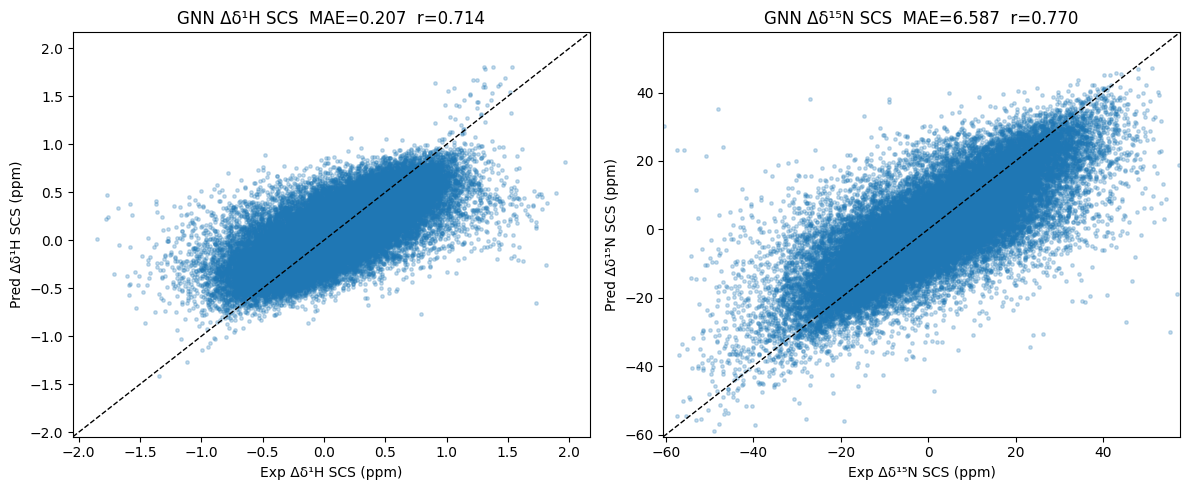

Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/scatter_gnn.png

=== MLP Test Results (secondary chemical shifts) ===
  mae_H   : 0.2587  [<0.3]  PASS
  mae_N   : 8.7499  [<2.0]  FAIL
  r_H     : 0.5344  [>0.9]  FAIL
  r_N     : 0.5742  [>0.9]  FAIL


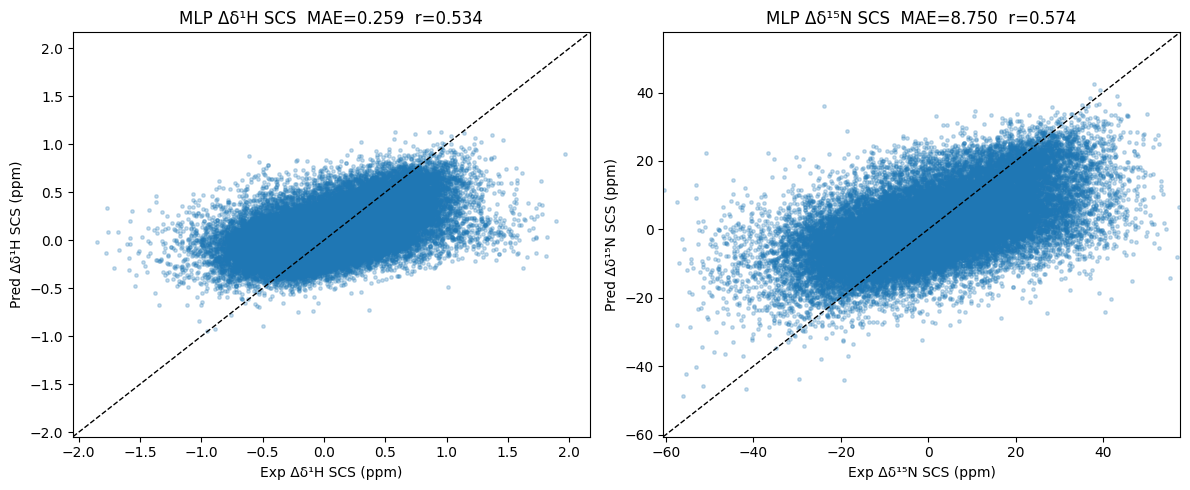

Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/scatter_mlp.png


In [63]:
def collect(model, ckpt, loader, is_gnn=True):
    """Collect predictions and ground truth, reconstructing absolute SCS.

    A2: y in the graph is per-protein centred (y - y_mean).
    After global denormalisation we add back y_mean per protein
    to recover the original absolute SCS for fair comparison.
    """
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for pid in (test_ids if loader is test_loader
                    else val_ids if loader is val_loader
                    else train_ids):
            if pid not in graph_map: continue
            gdata = graph_map[pid].to(DEVICE)
            ea    = gdata.edge_attr if is_gnn else None
            pred  = model(gdata.x, gdata.edge_index, ea, None).cpu().numpy()
            true  = gdata.y.cpu().numpy()
            # Denormalise centred predictions → centred SCS
            pred_scs = pred * Y_STD + Y_MU
            true_scs = true * Y_STD + Y_MU
            # A2: add back per-protein mean to restore absolute SCS
            ymean = gdata.y_mean.cpu().numpy()  # [2]
            pred_scs += ymean
            true_scs += ymean
            preds.append(pred_scs)
            trues.append(true_scs)
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return trues, preds

TARGETS = {"mae_H": ("<", 0.3), "mae_N": ("<", 2.0),
           "r_H":   (">", 0.90), "r_N":  (">", 0.90)}

def report(name, y_true, y_pred):
    mH = float(np.mean(np.abs(y_pred[:,0] - y_true[:,0])))
    mN = float(np.mean(np.abs(y_pred[:,1] - y_true[:,1])))
    rH = float(pearsonr(y_true[:,0], y_pred[:,0])[0])
    rN = float(pearsonr(y_true[:,1], y_pred[:,1])[0])
    m  = {"mae_H": mH, "mae_N": mN, "r_H": rH, "r_N": rN}
    print(f"\n=== {name} Test Results (secondary chemical shifts) ===")
    for k, (op, thr) in TARGETS.items():
        ok = m[k] < thr if op == "<" else m[k] > thr
        print(f"  {k:<8}: {m[k]:.4f}  [{op}{thr}]  {'PASS' if ok else 'FAIL'}")
    return m

def scatter(name, y_true, y_pred, metrics):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, col, lbl in [(axes[0], 0, "¹H SCS"), (axes[1], 1, "¹⁵N SCS")]:
        xt, xp = y_true[:,col], y_pred[:,col]
        ax.scatter(xt, xp, alpha=0.25, s=6, rasterized=True)
        lo = min(xt.min(), xp.min()) - .2
        hi = max(xt.max(), xp.max()) + .2
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set(xlim=[lo,hi], ylim=[lo,hi],
               xlabel=f"Exp Δδ{lbl} (ppm)", ylabel=f"Pred Δδ{lbl} (ppm)")
        key = "H" if col == 0 else "N"
        ax.set_title(f"{name} Δδ{lbl}  MAE={metrics[f'mae_{key}']:.3f}  r={metrics[f'r_{key}']:.3f}")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/scatter_{name.lower()}.png"
    fig.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

# Evaluate GNN
yt_gnn, yp_gnn = collect(gnn_model, CKPT_GNN, test_loader, is_gnn=True)
gnn_metrics = report("GNN", yt_gnn, yp_gnn)
scatter("GNN", yt_gnn, yp_gnn, gnn_metrics)

# Evaluate MLP
yt_mlp, yp_mlp = collect(mlp_model, CKPT_MLP, test_loader, is_gnn=False)
mlp_metrics = report("MLP", yt_mlp, yp_mlp)
scatter("MLP", yt_mlp, yp_mlp, mlp_metrics)

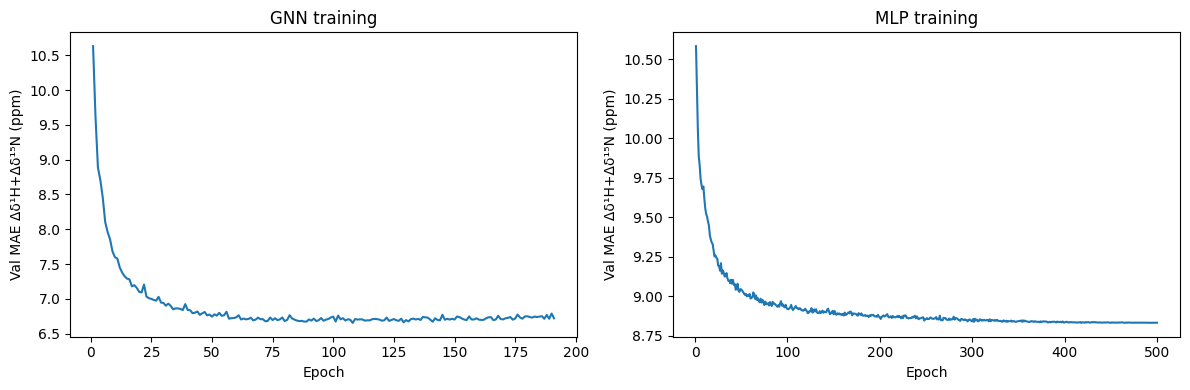

In [64]:
# ── Training loss curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], gnn_hist, "GNN"), (axes[1], mlp_hist, "MLP")]:
    eps  = [h[0] for h in hist]
    maes = [h[2] + h[3] for h in hist]
    ax.plot(eps, maes)
    ax.set(xlabel="Epoch", ylabel="Val MAE Δδ¹H+Δδ¹⁵N (ppm)", title=f"{name} training")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

## 8 · Inference on New PDB

In [65]:
def predict_pdb(pdb_file, model, is_gnn=True, feature_level=FEATURE_LEVEL):
    """
    Predict HN and 15N secondary chemical shifts for every non-Pro residue.

    Returns DataFrame: chain, seq_id, res_name,
                       pred_1H_scs, pred_15N_scs,   (secondary, ppm)
                       pred_1H_abs, pred_15N_abs     (absolute,  ppm)
    """
    # Ensure normalisation stats are in memory
    global Y_MU, Y_STD
    try:
        _ = Y_MU
    except NameError:
        if os.path.exists(STATS_PKL):
            with open(STATS_PKL, "rb") as f:
                _s = pickle.load(f)
            Y_MU  = _s["y_mu"]
            Y_STD = _s["y_std"]
            print("Loaded Y_MU / Y_STD from cache.")
        else:
            raise RuntimeError(
                "Y_MU / Y_STD not defined. Run split_and_norm cell first."
            )

    # Structure preparation
    h_pdb = complete_hydrogens(pdb_file)
    res_atoms, ensemble_stats, flex_ok = load_residue_atoms(h_pdb, BB_CUTOFF)
    if not res_atoms:
        raise ValueError(f"No residues parsed from {pdb_file}")

    sasa_map = compute_sasa_protein(h_pdb)

    chain_ord = defaultdict(list)
    for k in sorted(res_atoms, key=lambda x: x[1]):
        chain_ord[k[0]].append(k)
    seq_order = [k for v in chain_ord.values() for k in v]
    seq_idx   = {k: i for i, k in enumerate(seq_order)}   # O(1) lookup

    # Local frames
    frames = {}
    for k, atoms in res_atoms.items():
        N_  = _get_coord(atoms, "N")
        Ca_ = _get_coord(atoms, "CA")
        C_  = _get_coord(atoms, "C")
        if all(x is not None for x in [N_, Ca_, C_]):
            frames[k] = build_local_frame(N_, Ca_, C_)

    # H-bond pairs (KD-tree)
    o_coords, o_keys = [], []
    for k, atoms in res_atoms.items():
        O_ = _get_coord(atoms, "O")
        if O_ is not None:
            o_coords.append(O_); o_keys.append(k)

    hbond_pairs = set()
    if o_coords:
        from scipy.spatial import cKDTree as _KDTree2
        o_tree = _KDTree2(np.array(o_coords, dtype=np.float32))
        for k in seq_order:
            if flex_ok is not None and k not in flex_ok: continue
            atoms = res_atoms.get(k, [])
            H_ = _get_H(atoms)
            if H_ is None: continue
            for hit in o_tree.query_ball_point(H_, r=2.5):
                k2 = o_keys[hit]
                if k2 != k: hbond_pairs.add((k, k2))

    # Embed residues — pass seq_idx
    feats, valid = {}, []
    for k in seq_order:
        if flex_ok is not None and k not in flex_ok: continue
        fv, _ = embed_residue(
            k, res_atoms, seq_order, seq_idx, ensemble_stats,
            sasa_map, {}, res_atoms, None, feature_level
        )
        if fv is not None:
            feats[k] = fv; valid.append(k)

    if not valid:
        raise ValueError("No residues survived embedding.")

    # Build graph and run model
    X  = torch.tensor(np.stack([feats[k] for k in valid]),
                      dtype=torch.float32).to(DEVICE)
    ei, ea = build_graph_edges(valid, res_atoms, seq_order, seq_idx, frames, hbond_pairs)
    ei = ei.to(DEVICE); ea = ea.to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred_norm = model(X, ei, ea if is_gnn else None).cpu().numpy()

    # A2: denormalise centred predictions → SCS
    # At inference no per-protein y_mean is known (no experimental data).
    # The model predicts within-protein deviations centred near 0.
    # Adding Y_MU restores the training-set grand mean, giving absolute SCS.
    pred_scs = pred_norm * Y_STD + Y_MU

    rows = []
    for i, (ch, sq, rn) in enumerate(valid):
        rc = _RC_SHIFTS.get(rn, (8.2, 120.0))
        rows.append({
            "chain":        ch,
            "seq_id":       sq,
            "res_name":     rn,
            "pred_1H_scs":  round(float(pred_scs[i, 0]), 4),
            "pred_15N_scs": round(float(pred_scs[i, 1]), 4),
            "pred_1H_abs":  round(float(pred_scs[i, 0] + rc[0]), 4),
            "pred_15N_abs": round(float(pred_scs[i, 1] + rc[1]), 4),
        })
    return pd.DataFrame(rows)


# ── Example: predict first test protein ───────────────────
ex_pid = test_ids[0]
ex_pdb = next(r["pdb_path"] for r in manifest if r["bmrb_id"] == ex_pid)
gnn_model.load_state_dict(torch.load(CKPT_GNN, map_location=DEVICE))

df = predict_pdb(ex_pdb, gnn_model, is_gnn=True)
print(f"Predictions for BMRB {ex_pid}:")
print(df.head(10).to_string(index=False))

out_csv = f"{OUTPUT_DIR}/pred_{ex_pid}.csv"
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


Predictions for BMRB 4717:
chain  seq_id res_name  pred_1H_scs  pred_15N_scs  pred_1H_abs  pred_15N_abs
    A       1      MET       0.0472        6.6513       8.2672      126.2513
    A       2      ASP      -0.0004        2.2982       8.2396      122.6982
    A       3      LYS      -0.0689        1.1000       8.1611      122.0000
    A       4      PRO      -0.0219       -0.1045       8.1781      119.8955
    A       5      LYS      -0.0296        4.2456       8.2004      125.1456
    A       6      ARG      -0.0675        1.6255       8.1625      122.1255
    A       7      LYS       0.1018        2.4307       8.3318      123.3307
    A       8      GLU      -0.3220       -8.8999       8.0380      112.3001
    A       9      ALA       0.1608        7.1902       8.3108      129.6902
    A      10      VAL       0.1345        0.1966       8.1645      120.0966
Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/pred_4717.csv


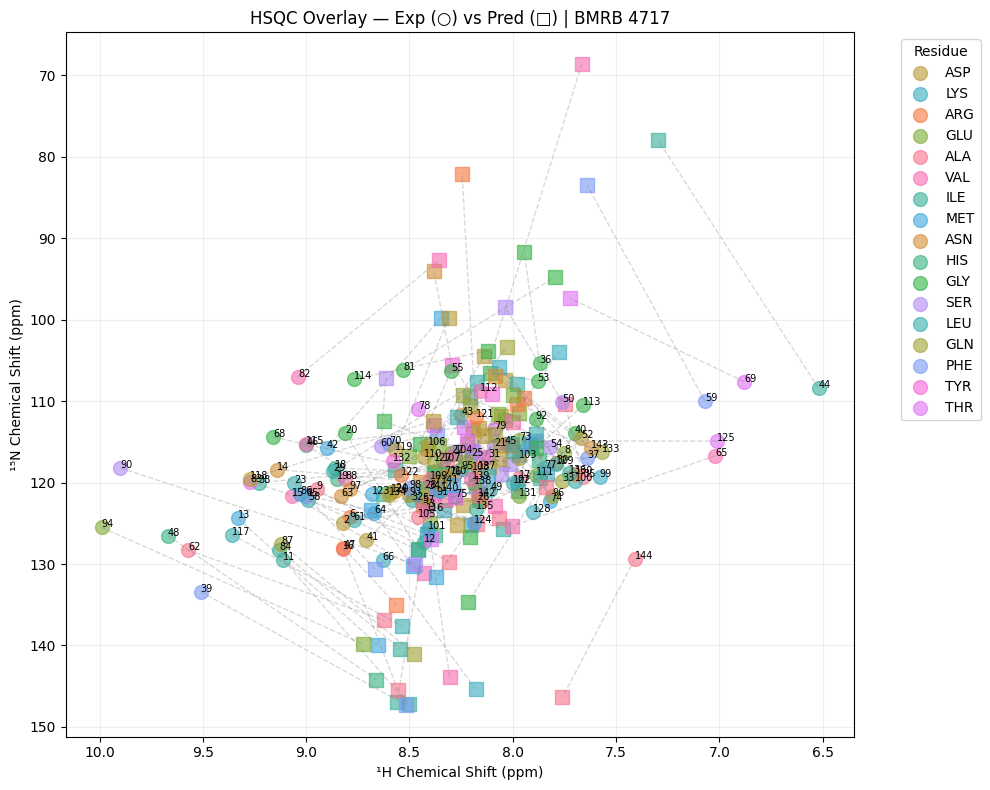

In [66]:
# ── HSQC overlay plot: Experimental vs Predicted ───────────
ex_pid   = test_ids[0]
ex_entry = next(r for r in manifest if r["bmrb_id"] == ex_pid)

df_pred = predict_pdb(ex_entry["pdb_path"], gnn_model, is_gnn=True)
exp_shifts = parse_hsqc_shifts(ex_entry["bmrb_path"])

exp_list = []
for _, row in df_pred.iterrows():
    match = next((v for k, v in exp_shifts.items()
                  if k[1] == row["seq_id"] and k[2] == row["res_name"]), None)
    exp_list.append(match)

df_pred["exp_1H"]  = [x[0] if x else None for x in exp_list]
df_pred["exp_15N"] = [x[1] if x else None for x in exp_list]
plot_df = df_pred.dropna(subset=["exp_1H"])

plt.figure(figsize=(10, 8))
res_types = sorted(plot_df["res_name"].unique())
palette   = sns.color_palette("husl", len(res_types))
color_map = dict(zip(res_types, palette))

for _, row in plot_df.iterrows():
    c = color_map[row["res_name"]]
    already = plt.gca().get_legend_handles_labels()[1]
    plt.scatter(row["exp_1H"],  row["exp_15N"],  marker="o", s=100,
                color=c, alpha=0.6,
                label=row["res_name"] if row["res_name"] not in already else "")
    plt.scatter(row["pred_1H_abs"], row["pred_15N_abs"], marker="s", s=100,
                color=c, alpha=0.6)
    plt.plot([row["exp_1H"], row["pred_1H_abs"]],
             [row["exp_15N"], row["pred_15N_abs"]],
             color="gray", linestyle="--", alpha=0.3, lw=1)
    plt.text(row["exp_1H"], row["exp_15N"], str(row["seq_id"]), fontsize=7)

plt.gca().invert_xaxis(); plt.gca().invert_yaxis()
plt.xlabel("¹H Chemical Shift (ppm)")
plt.ylabel("¹⁵N Chemical Shift (ppm)")
plt.title(f"HSQC Overlay — Exp (○) vs Pred (□) | BMRB {ex_pid}")
plt.grid(True, alpha=0.2)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(dict(zip(labels, handles)).values(),
           dict(zip(labels, handles)).keys(),
           title="Residue", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hsqc_overlay_{ex_pid}.png", dpi=150)
plt.show()

Predictions for BMRB 19293:
chain  seq_id res_name  pred_1H_scs  pred_15N_scs  pred_1H_abs  pred_15N_abs
    A       1      MET       0.0636       11.9186       8.2836      131.5186
    A       2      THR       0.0681        9.4446       8.1281      123.0446
    A       3      LYS       0.0591        8.9400       8.2891      129.8400
    A       4      LEU       0.0481        4.8942       8.2081      126.6942
    A       5      GLU       0.1369        2.3329       8.4969      123.5329
    A       6      GLU      -0.0033       -1.4283       8.3567      119.7717
    A       7      HIS      -0.0739        3.4074       8.2061      121.6074
    A       8      LEU      -0.0489       -8.7205       8.1111      113.0795
    A       9      GLU       0.0020       -9.4697       8.3620      111.7303
    A      10      GLY      -0.1658       -4.0392       8.1242      104.7608
Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/pred_19293.csv


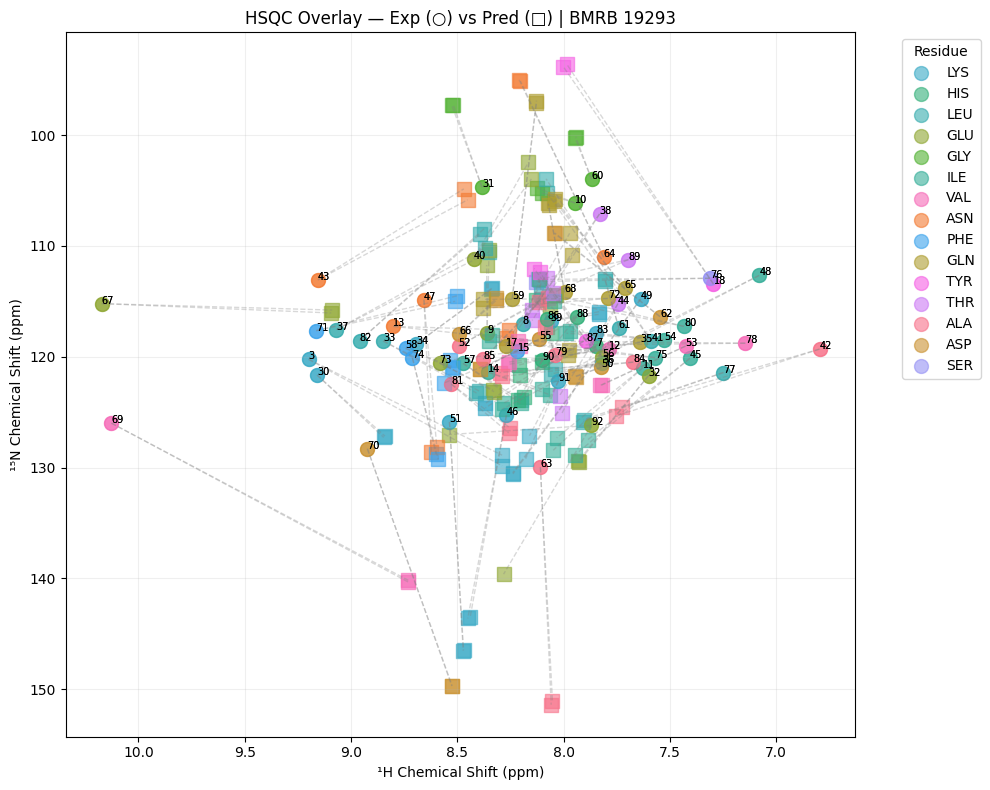

In [67]:
ex_pid = '19293'
ex_pdb = next(r["pdb_path"] for r in manifest if r["bmrb_id"] == ex_pid)
gnn_model.load_state_dict(torch.load(CKPT_GNN, map_location=DEVICE))

df = predict_pdb(ex_pdb, gnn_model, is_gnn=True)
print(f"Predictions for BMRB {ex_pid}:")
print(df.head(10).to_string(index=False))

out_csv = f"{OUTPUT_DIR}/pred_{ex_pid}.csv"
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# ── HSQC overlay plot: Experimental vs Predicted ───────────

ex_entry = next(r for r in manifest if r["bmrb_id"] == ex_pid)

df_pred = predict_pdb(ex_entry["pdb_path"], gnn_model, is_gnn=True)
exp_shifts = parse_hsqc_shifts(ex_entry["bmrb_path"])

exp_list = []
for _, row in df_pred.iterrows():
    match = next((v for k, v in exp_shifts.items()
                  if k[1] == row["seq_id"] and k[2] == row["res_name"]), None)
    exp_list.append(match)

df_pred["exp_1H"]  = [x[0] if x else None for x in exp_list]
df_pred["exp_15N"] = [x[1] if x else None for x in exp_list]
plot_df = df_pred.dropna(subset=["exp_1H"])

plt.figure(figsize=(10, 8))
res_types = sorted(plot_df["res_name"].unique())
palette   = sns.color_palette("husl", len(res_types))
color_map = dict(zip(res_types, palette))

for _, row in plot_df.iterrows():
    c = color_map[row["res_name"]]
    already = plt.gca().get_legend_handles_labels()[1]
    plt.scatter(row["exp_1H"],  row["exp_15N"],  marker="o", s=100,
                color=c, alpha=0.6,
                label=row["res_name"] if row["res_name"] not in already else "")
    plt.scatter(row["pred_1H_abs"], row["pred_15N_abs"], marker="s", s=100,
                color=c, alpha=0.6)
    plt.plot([row["exp_1H"], row["pred_1H_abs"]],
             [row["exp_15N"], row["pred_15N_abs"]],
             color="gray", linestyle="--", alpha=0.3, lw=1)
    plt.text(row["exp_1H"], row["exp_15N"], str(row["seq_id"]), fontsize=7)

plt.gca().invert_xaxis(); plt.gca().invert_yaxis()
plt.xlabel("¹H Chemical Shift (ppm)")
plt.ylabel("¹⁵N Chemical Shift (ppm)")
plt.title(f"HSQC Overlay — Exp (○) vs Pred (□) | BMRB {ex_pid}")
plt.grid(True, alpha=0.2)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(dict(zip(labels, handles)).values(),
           dict(zip(labels, handles)).keys(),
           title="Residue", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hsqc_overlay_{ex_pid}.png", dpi=150)
plt.show()

In [68]:
# ── Predict any uploaded PDB ────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# MY_PDB = list(uploaded.keys())[0]
# df_custom = predict_pdb(MY_PDB, gnn_model, is_gnn=True)
# print(df_custom.to_string(index=False))
# df_custom.to_csv(f"{OUTPUT_DIR}/pred_custom.csv", index=False)
print("Uncomment lines above after uploading your own PDB file.")

Uncomment lines above after uploading your own PDB file.


## Feature Summary

### X (node features per residue) — total dims depend on FEATURE_LEVEL

| Block | Feature | Dim | Level |
|---|---|---|---|
| A | aa_onehot | 20 | always |
| A | sin_phi, cos_phi | 2 | always |
| A | sin_psi, cos_psi | 2 | always |
| A | sin_omega, cos_omega | 2 | always |
| A | sin/cos χ₁–χ₄ | 8 | always |
| A | chi_mask | 4 | always |
| A | cb_vec_local | 3 | always |
| **A total** | | **21** | |
| B | ring_current (Haigh-Mallion sum) | 1 | HIGH |
| C | sasa_total_norm, sasa_backbone_norm | 2 | HIGH |
| D | hbond_exists, r_NO, r_HO, cos_NHO, cos_HOC, count, strength_sum | 7 | HIGH |
| E | rmsd_backbone, rmsd_sidechain | 2 | HIGH |
| **HIGH total** | | **12** | |
| F | elec_phi_DH, elec_Ez | 2 | HIGH_MED |
| G | n_pi_star_d, n_pi_star_cos | 2 | HIGH_MED |
| H | am1_q_N, am1_q_H, am1_q_CO | 3 | HIGH_MED |
| **MED total** | | **7** | |
| I | helix_dipole_phi, helix_dipole_d_ncap | 2 | ALL |
| J | S2, Rex_proxy, tau_e, T1rho_norm, training_weight, B_bb, B_sc, disorder, rotamer_entropy | 9 | always |
| K | dyn_mask × 4 | 4 | always |

**Total: HIGH=45 | HIGH_MED=52 | ALL=54**

### X (edge features) — 30 dims (fixed)
| Feature | Dim |
|---|---|
| delta_seq | 1 |
| RBF(r_CaCa) | 16 |
| r_hat_local | 3 |
| R_rel_flat (first 2 cols) | 6 |
| bond_type (peptide/seq_nb/space/hbond) | 4 |

### y (per residue) — 2 dims
| Target | Description |
|---|---|
| Δδ_HN | Secondary chemical shift: obs − RC (ppm), standardised |
| Δδ_15N | Secondary chemical shift: obs − RC (ppm), standardised |